In [7]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import re
data = pd.read_csv('/Users/krymmd/Library/CloudStorage/OneDrive-IdahoNationalLaboratory/Documents/MoltenSaltPropnet/data/new_data.csv')
import os
import numpy as np

# Output directory for figures
output_dir = os.path.join("additional_data_studies")
os.makedirs(output_dir, exist_ok=True)


In [8]:
data.head()

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
0,AlCl3,133.3405,Pure Salt,465.0,453.0,2.56,0.002710,0.00228,19400.0,NaN,...,"{'Al': 1.61, 'Cl': 3.16}","{'Al': '3+', 'Cl': '1-'}","{'Al': 1.18, 'Cl': 0.79}","{'Al': 1.25, 'Cl': 1.0}","{'Al': 1.18, 'Cl': 0.99}","{'Al': 577.5, 'Cl': 1251.2}","{'Al': 'Al', 'Cl': 'Cl'}",3.55,12.888750,3.222188
1,BeCl2,79.9182,Pure Salt,688.0,760.0,2.28,0.001100,NaN,NaN,NaN,...,"{'Be': 1.57, 'Cl': 3.16}","{'Be': '2+', 'Cl': '1-'}","{'Be': 1.12, 'Cl': 0.79}","{'Be': 1.05, 'Cl': 1.0}","{'Be': 0.9, 'Cl': 0.99}","{'Be': 899.5, 'Cl': 1251.2}","{'Be': 'Be', 'Cl': 'Cl'}",2.70,7.410920,2.470307
2,BeF2,47.0090,Pure Salt,821.2,1442.0,1.97,0.000015,NaN,NaN,-8.120,...,"{'Be': 1.57, 'F': 3.98}","{'Be': '2+', 'F': '1-'}","{'Be': 1.12, 'F': 0.42}","{'Be': 1.05, 'F': 0.5}","{'Be': 0.9, 'F': 0.71}","{'Be': 899.5, 'F': 1681.0}","{'Be': 'Be', 'F': 'F'}",1.96,3.898795,1.299598
3,CaCl2,110.9840,Pure Salt,1045.0,2230.0,2.53,0.000423,NaN,NaN,-0.545,...,"{'Ca': 1.0, 'Cl': 3.16}","{'Ca': '2+', 'Cl': '1-'}","{'Ca': 1.94, 'Cl': 0.79}","{'Ca': 1.8, 'Cl': 1.0}","{'Ca': 1.74, 'Cl': 0.99}","{'Ca': 589.8, 'Cl': 1251.2}","{'Ca': 'Ca', 'Cl': 'Cl'}",3.52,25.583188,8.527729
4,CaF2,78.0748,Pure Salt,1692.0,2724.0,3.18,0.000391,0.10000,47600.0,NaN,...,"{'Ca': 1.0, 'F': 3.98}","{'Ca': '2+', 'F': '1-'}","{'Ca': 1.94, 'F': 0.42}","{'Ca': 1.8, 'F': 0.5}","{'Ca': 1.74, 'F': 0.71}","{'Ca': 589.8, 'F': 1681.0}","{'Ca': 'Ca', 'F': 'F'}",2.78,22.071063,7.357021


In [9]:
pred_cols = data.columns[3:16]
data_cols = data.columns[17:].drop('symbol')

anion_filter = 'Cl'
flag = data['System'].apply(lambda x: True if anion_filter in x else False)
data = data[flag]
data

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
0,AlCl3,133.3405,Pure Salt,465.0,453.0,2.5600,0.002710,2.280000e-03,19400.00,NaN,...,"{'Al': 1.61, 'Cl': 3.16}","{'Al': '3+', 'Cl': '1-'}","{'Al': 1.18, 'Cl': 0.79}","{'Al': 1.25, 'Cl': 1.0}","{'Al': 1.18, 'Cl': 0.99}","{'Al': 577.5, 'Cl': 1251.2}","{'Al': 'Al', 'Cl': 'Cl'}",3.55,12.888750,3.222188
1,BeCl2,79.9182,Pure Salt,688.0,760.0,2.2800,0.001100,NaN,NaN,NaN,...,"{'Be': 1.57, 'Cl': 3.16}","{'Be': '2+', 'Cl': '1-'}","{'Be': 1.12, 'Cl': 0.79}","{'Be': 1.05, 'Cl': 1.0}","{'Be': 0.9, 'Cl': 0.99}","{'Be': 899.5, 'Cl': 1251.2}","{'Be': 'Be', 'Cl': 'Cl'}",2.70,7.410920,2.470307
3,CaCl2,110.9840,Pure Salt,1045.0,2230.0,2.5300,0.000423,NaN,NaN,-0.545,...,"{'Ca': 1.0, 'Cl': 3.16}","{'Ca': '2+', 'Cl': '1-'}","{'Ca': 1.94, 'Cl': 0.79}","{'Ca': 1.8, 'Cl': 1.0}","{'Ca': 1.74, 'Cl': 0.99}","{'Ca': 589.8, 'Cl': 1251.2}","{'Ca': 'Ca', 'Cl': 'Cl'}",3.52,25.583188,8.527729
5,GdCl3,263.6090,Pure Salt,875.0,1868.0,4.1500,0.000673,NaN,NaN,6.380,...,"{'Gd': 1.2, 'Cl': 3.16}","{'Gd': '3+', 'Cl': '1-'}","{'Gd': 2.33, 'Cl': 0.79}","{'Gd': 1.8, 'Cl': 1.0}","{'Gd': 1.91, 'Cl': 0.99}","{'Gd': 593.4, 'Cl': 1251.2}","{'Gd': 'Gd', 'Cl': 'Cl'}",4.70,31.106816,7.776704
7,KCl,74.5513,Pure Salt,1042.7,1688.0,2.1400,0.000583,7.080000e-02,23900.00,NaN,...,"{'K': 0.82, 'Cl': 3.16}","{'K': '1+', 'Cl': '1-'}","{'K': 2.43, 'Cl': 0.79}","{'K': 2.2, 'Cl': 1.0}","{'K': 1.96, 'Cl': 0.99}","{'K': 418.8, 'Cl': 1251.2}","{'K': 'K', 'Cl': 'Cl'}",3.22,41.629516,20.814758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,UCl3,NaN,Pure Salt,NaN,NaN,13.6520,0.007943,NaN,NaN,NaN,...,"{'U': 1.38, 'Cl': 3.16}","{'U': '3+, 4+, 6+', 'Cl': '1-'}","{'U': 1.75, 'Cl': 0.79}","{'U': 1.75, 'Cl': 1.0}","{'U': 1.96, 'Cl': 0.99}","{'U': 597.6, 'Cl': 1251.2}","{'U': 'U', 'Cl': 'Cl'}",4.12,53.383047,13.345762
4866,UCl4,NaN,Pure Salt,NaN,NaN,5.2508,0.001945,NaN,NaN,NaN,...,"{'U': 1.38, 'Cl': 3.16}","{'U': '3+, 4+, 6+', 'Cl': '1-'}","{'U': 1.75, 'Cl': 0.79}","{'U': 1.75, 'Cl': 1.0}","{'U': 1.96, 'Cl': 0.99}","{'U': 597.6, 'Cl': 1251.2}","{'U': 'U', 'Cl': 'Cl'}",4.91,55.844062,11.168812
4869,YCl3,NaN,Pure Salt,NaN,NaN,3.0070,0.000500,NaN,NaN,NaN,...,"{'Y': 1.22, 'Cl': 3.16}","{'Y': '3+', 'Cl': '1-'}","{'Y': 2.12, 'Cl': 0.79}","{'Y': 1.85, 'Cl': 1.0}","{'Y': 1.62, 'Cl': 0.99}","{'Y': 600.0, 'Cl': 1251.2}","{'Y': 'Y', 'Cl': 'Cl'}",4.49,26.352435,6.588109
4872,ZnCl2,NaN,Pure Salt,NaN,NaN,2.8375,0.000529,9.818701e-05,96325.38,NaN,...,"{'Zn': 1.65, 'Cl': 3.16}","{'Zn': '2+', 'Cl': '1-'}","{'Zn': 1.42, 'Cl': 0.79}","{'Zn': 1.35, 'Cl': 1.0}","{'Zn': 1.31, 'Cl': 0.99}","{'Zn': 906.4, 'Cl': 1251.2}","{'Zn': 'Zn', 'Cl': 'Cl'}",3.00,11.144687,3.714896


In [10]:
data[pred_cols].head(10)

,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,mu2_b,mu2_c,k_a,k_b,cp_a,cp_b
0,465.0,453.0,2.56,0.002710,0.00228,19400.0,NaN,NaN,NaN,NaN,NaN,125.52000,NaN
1,688.0,760.0,2.28,0.001100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1045.0,2230.0,2.53,0.000423,NaN,NaN,-0.545,597.0,546000.0,0.568,-0.000115,102.53300,NaN
5,875.0,1868.0,4.15,0.000673,NaN,NaN,6.380,-15500.0,9800000.0,NaN,NaN,NaN,NaN
7,1042.7,1688.0,2.14,0.000583,0.07080,23900.0,NaN,NaN,NaN,0.566,-0.000170,73.59656,NaN
9,1132.0,1983.0,4.09,0.000777,0.02060,54600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,883.0,1655.0,1.88,0.000433,0.07260,22400.0,NaN,NaN,NaN,0.882,-0.000290,73.38320,-0.009473
13,987.0,1640.0,1.97,0.000288,0.18000,20500.0,NaN,NaN,NaN,0.224,-0.000020,92.04800,NaN
15,1073.8,1715.0,2.14,0.000543,0.08930,22000.0,NaN,NaN,NaN,0.712,-0.000180,77.76380,-0.007531
17,1031.0,1897.0,4.26,0.000930,0.08510,36900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
data[data_cols].head(10)

,polarizability_element[10-24Cm3],atomic_mass_element,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
0,"{'Al': 8.34, 'Cl': 2.18}","{'Al': 26.982, 'Cl': 35.453}","{'Al': 1.61, 'Cl': 3.16}","{'Al': '3+', 'Cl': '1-'}","{'Al': 1.18, 'Cl': 0.79}","{'Al': 1.25, 'Cl': 1.0}","{'Al': 1.18, 'Cl': 0.99}","{'Al': 577.5, 'Cl': 1251.2}",3.55,12.888750,3.222188
1,"{'Be': 5.6, 'Cl': 2.18}","{'Be': 9.012, 'Cl': 35.453}","{'Be': 1.57, 'Cl': 3.16}","{'Be': '2+', 'Cl': '1-'}","{'Be': 1.12, 'Cl': 0.79}","{'Be': 1.05, 'Cl': 1.0}","{'Be': 0.9, 'Cl': 0.99}","{'Be': 899.5, 'Cl': 1251.2}",2.70,7.410920,2.470307
3,"{'Ca': 25.0, 'Cl': 2.18}","{'Ca': 40.078, 'Cl': 35.453}","{'Ca': 1.0, 'Cl': 3.16}","{'Ca': '2+', 'Cl': '1-'}","{'Ca': 1.94, 'Cl': 0.79}","{'Ca': 1.8, 'Cl': 1.0}","{'Ca': 1.74, 'Cl': 0.99}","{'Ca': 589.8, 'Cl': 1251.2}",3.52,25.583188,8.527729
5,"{'Gd': 26.0, 'Cl': 2.18}","{'Gd': 157.25, 'Cl': 35.453}","{'Gd': 1.2, 'Cl': 3.16}","{'Gd': '3+', 'Cl': '1-'}","{'Gd': 2.33, 'Cl': 0.79}","{'Gd': 1.8, 'Cl': 1.0}","{'Gd': 1.91, 'Cl': 0.99}","{'Gd': 593.4, 'Cl': 1251.2}",4.70,31.106816,7.776704
7,"{'K': 43.4, 'Cl': 2.18}","{'K': 39.098, 'Cl': 35.453}","{'K': 0.82, 'Cl': 3.16}","{'K': '1+', 'Cl': '1-'}","{'K': 2.43, 'Cl': 0.79}","{'K': 2.2, 'Cl': 1.0}","{'K': 1.96, 'Cl': 0.99}","{'K': 418.8, 'Cl': 1251.2}",3.22,41.629516,20.814758
9,"{'La': 37.0, 'Cl': 2.18}","{'La': 138.905, 'Cl': 35.453}","{'La': 1.1, 'Cl': 3.16}","{'La': '3+', 'Cl': '1-'}","{'La': 1.95, 'Cl': 0.79}","{'La': 1.95, 'Cl': 1.0}","{'La': 1.69, 'Cl': 0.99}","{'La': 538.1, 'Cl': 1251.2}",4.32,40.775547,10.193887
11,"{'Li': 24.3, 'Cl': 2.18}","{'Li': 6.941, 'Cl': 35.453}","{'Li': 0.98, 'Cl': 3.16}","{'Li': '1+', 'Cl': '1-'}","{'Li': 1.67, 'Cl': 0.79}","{'Li': 1.45, 'Cl': 1.0}","{'Li': 1.34, 'Cl': 0.99}","{'Li': 520.2, 'Cl': 1251.2}",2.46,16.129766,8.064883
13,"{'Mg': 10.6, 'Cl': 2.18}","{'Mg': 24.305, 'Cl': 35.453}","{'Mg': 1.31, 'Cl': 3.16}","{'Mg': '2+', 'Cl': '1-'}","{'Mg': 1.45, 'Cl': 0.79}","{'Mg': 1.5, 'Cl': 1.0}","{'Mg': 1.3, 'Cl': 0.99}","{'Mg': 737.7, 'Cl': 1251.2}",3.03,12.709786,4.236595
15,"{'Na': 23.6, 'Cl': 2.18}","{'Na': 22.99, 'Cl': 35.453}","{'Na': 0.93, 'Cl': 3.16}","{'Na': '1+', 'Cl': '1-'}","{'Na': 1.9, 'Cl': 0.79}","{'Na': 1.8, 'Cl': 1.0}","{'Na': 1.54, 'Cl': 0.99}","{'Na': 495.8, 'Cl': 1251.2}",2.69,22.291571,11.145786
17,"{'Nd': 32.0, 'Cl': 2.18}","{'Nd': 144.242, 'Cl': 35.453}","{'Nd': 1.14, 'Cl': 3.16}","{'Nd': '3+, 4+', 'Cl': '1-'}","{'Nd': 2.06, 'Cl': 0.79}","{'Nd': 1.85, 'Cl': 1.0}","{'Nd': 1.94, 'Cl': 0.99}","{'Nd': 533.1, 'Cl': 1251.2}",4.43,39.383047,9.845762


# Study for all F 


================ polarizability_element[10-24Cm3] ================



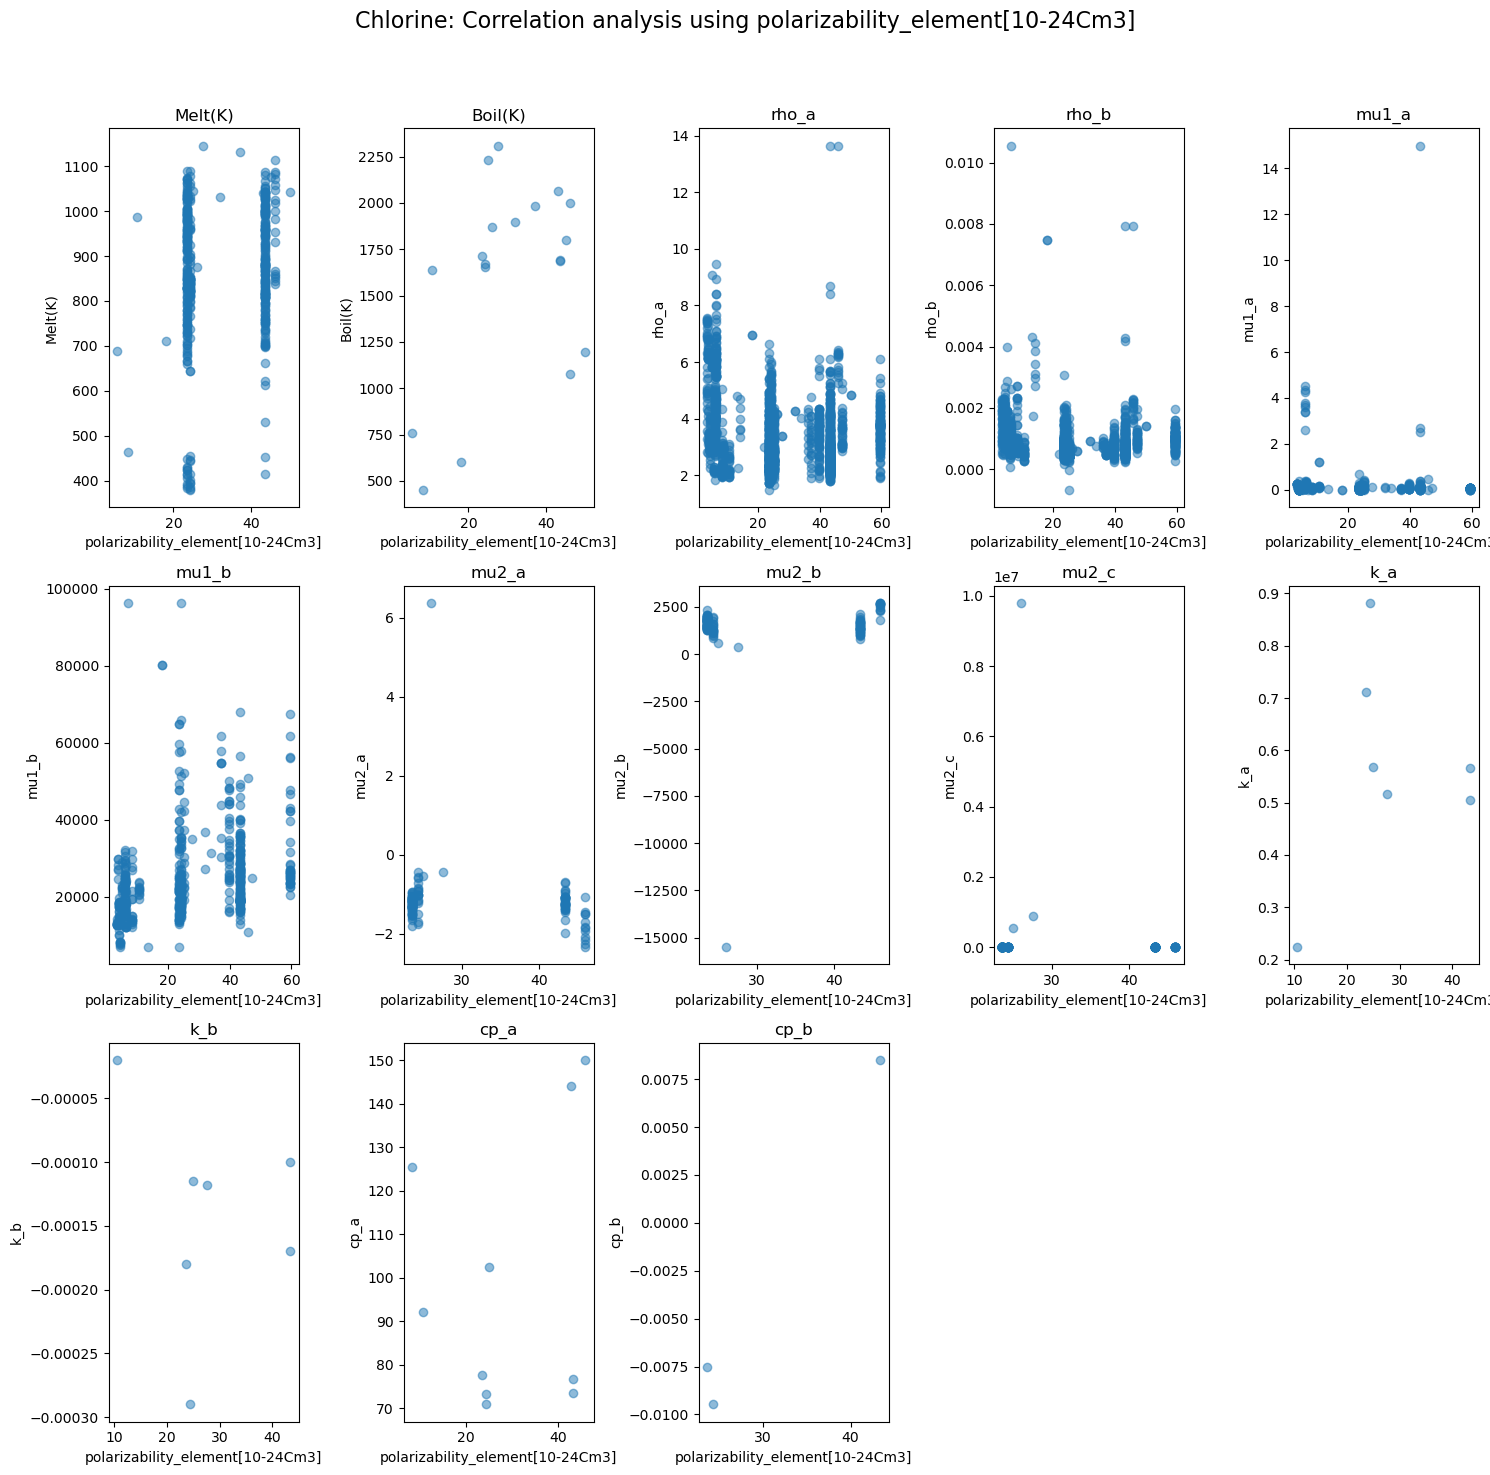

Correlation table:
         Correlation
Melt(K)     0.171815
Boil(K)     0.404710
rho_a      -0.234156
rho_b      -0.151213
mu1_a      -0.067765
mu1_b       0.313480
mu2_a      -0.151414
mu2_b       0.095356
mu2_c      -0.053410
k_a         0.227003
k_b        -0.218612
cp_a        0.193443
cp_b        0.991590

================ atomic_mass_element ================



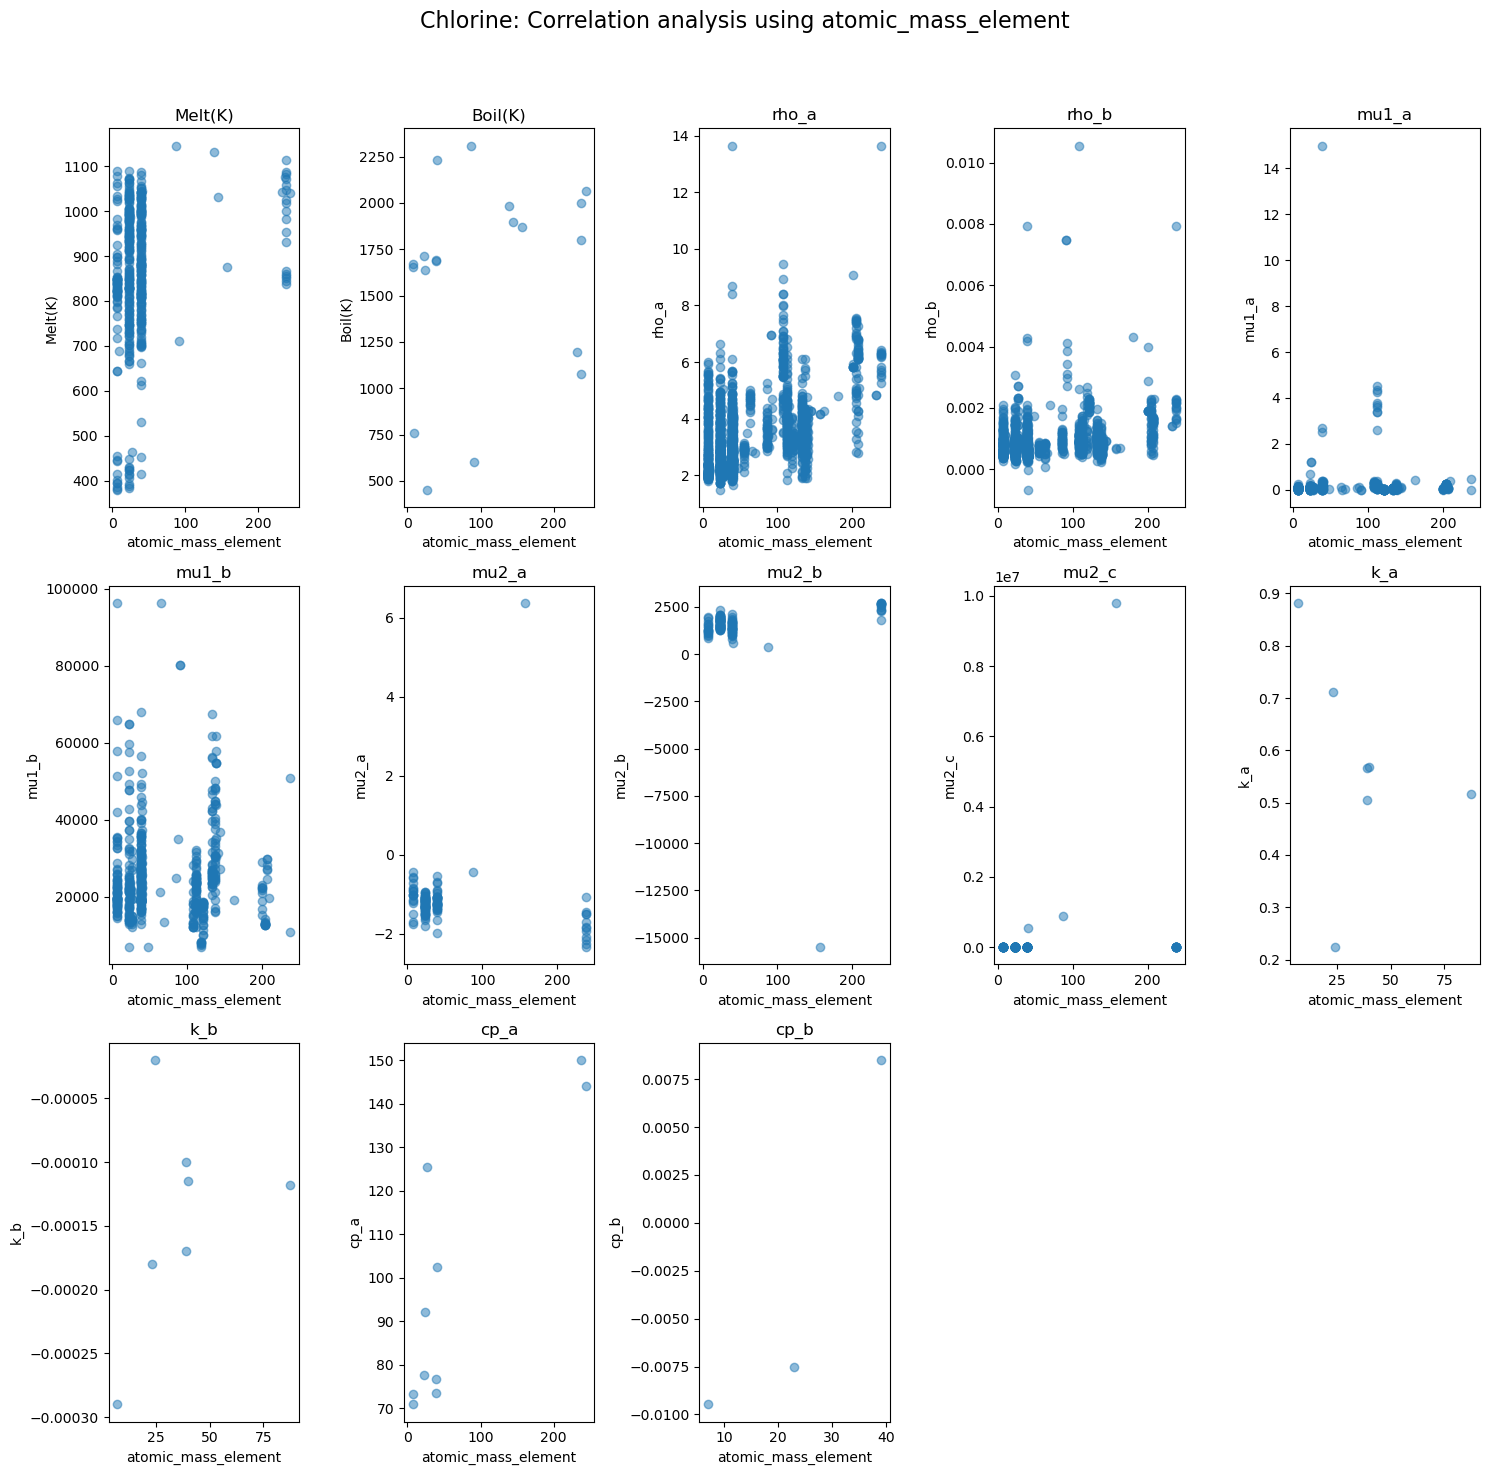

Correlation table:
         Correlation
Melt(K)     0.219048
Boil(K)     0.174275
rho_a       0.531024
rho_b       0.325880
mu1_a       0.034361
mu1_b      -0.003768
mu2_a      -0.092765
mu2_b       0.033896
mu2_c       0.151279
k_a        -0.321733
k_b         0.374327
cp_a        0.845962
cp_b        0.911486

================ electronegativity_element ================



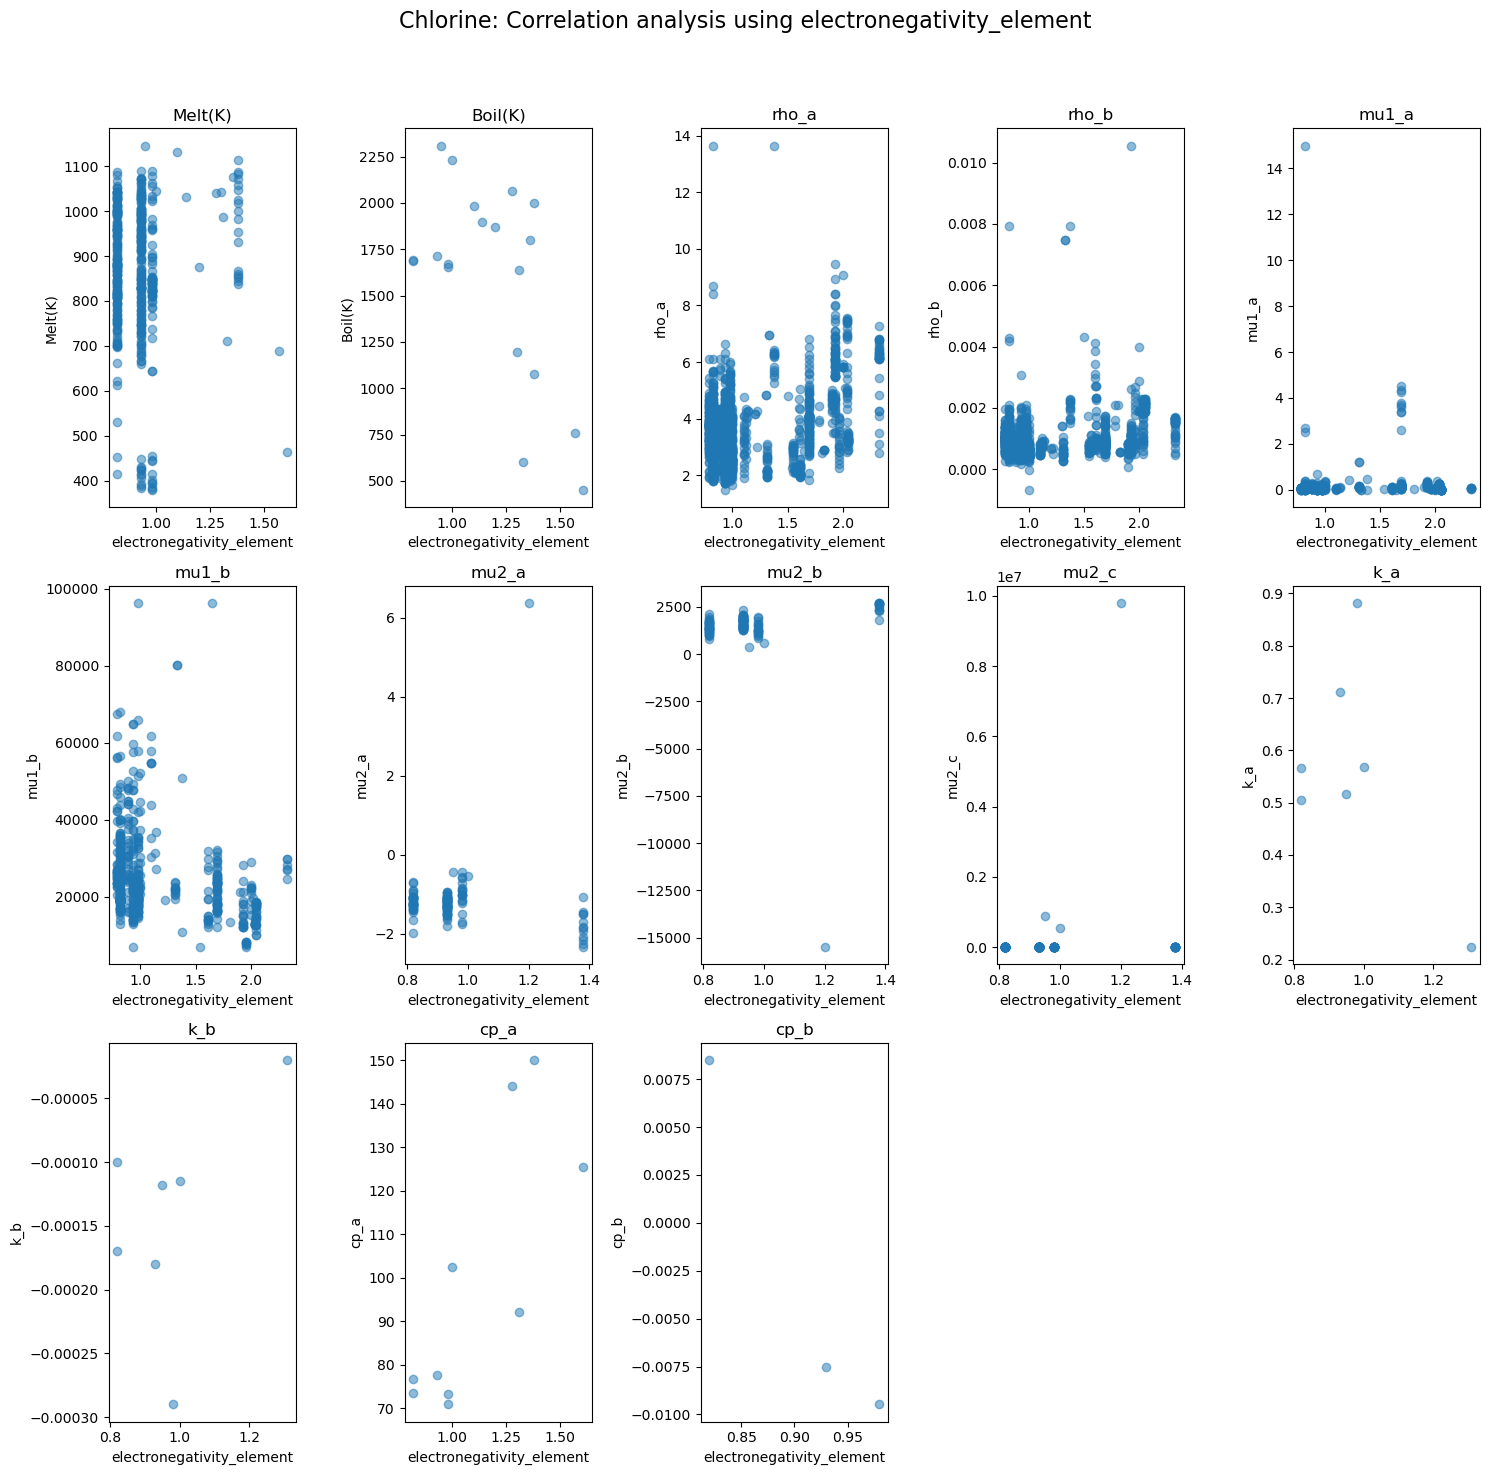

Correlation table:
         Correlation
Melt(K)     0.022688
Boil(K)    -0.611557
rho_a       0.468239
rho_b       0.312857
mu1_a       0.062907
mu1_b      -0.310035
mu2_a      -0.071669
mu2_b       0.043420
mu2_c       0.141273
k_a        -0.544175
k_b         0.479101
cp_a        0.784554
cp_b       -0.977663

================ atomic_radius_element[Angstrom] ================



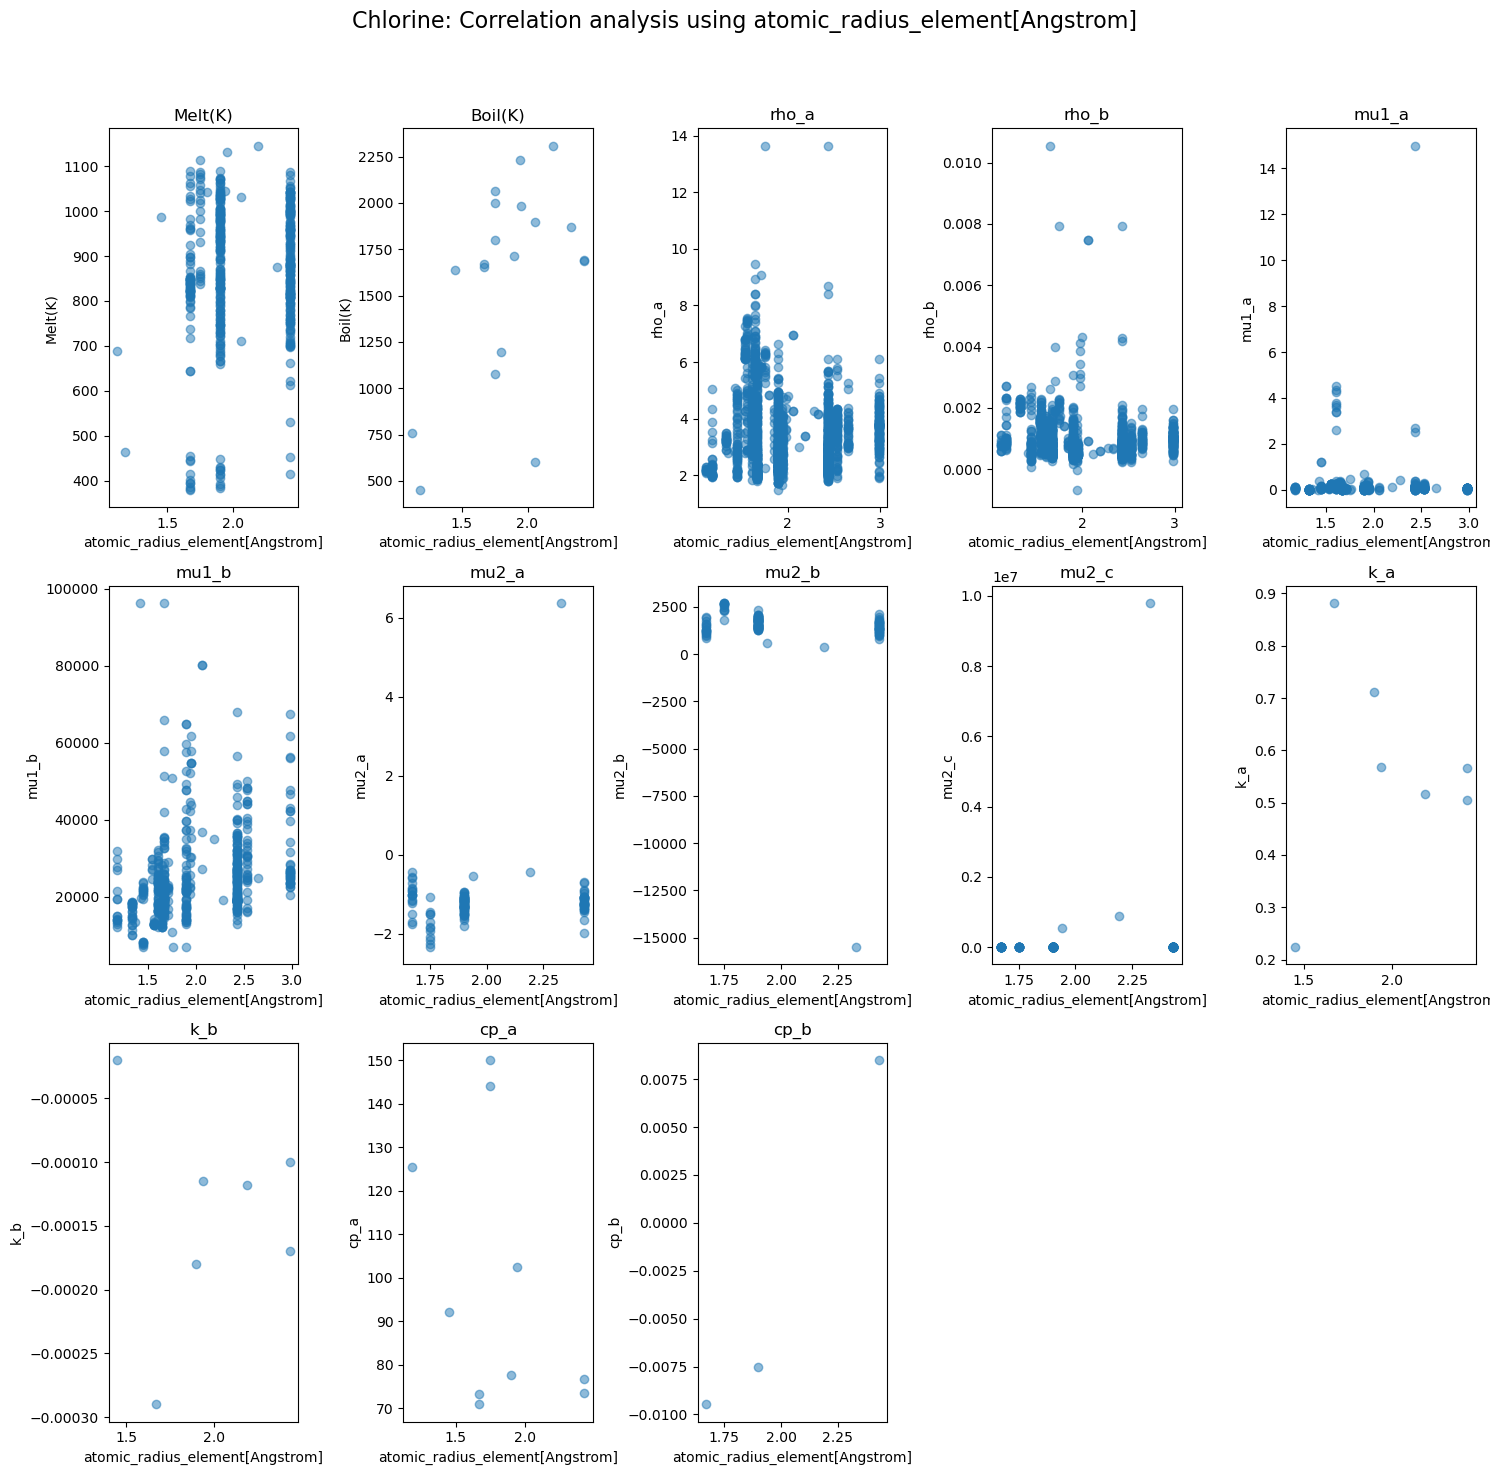

Correlation table:
         Correlation
Melt(K)     0.124805
Boil(K)     0.498277
rho_a      -0.134014
rho_b      -0.126683
mu1_a      -0.034804
mu1_b       0.297488
mu2_a       0.138261
mu2_b      -0.179544
mu2_c       0.102472
k_a         0.074025
k_b        -0.029420
cp_a       -0.404892
cp_b        0.979888

================ ionic_radius_element[Angstrom] ================



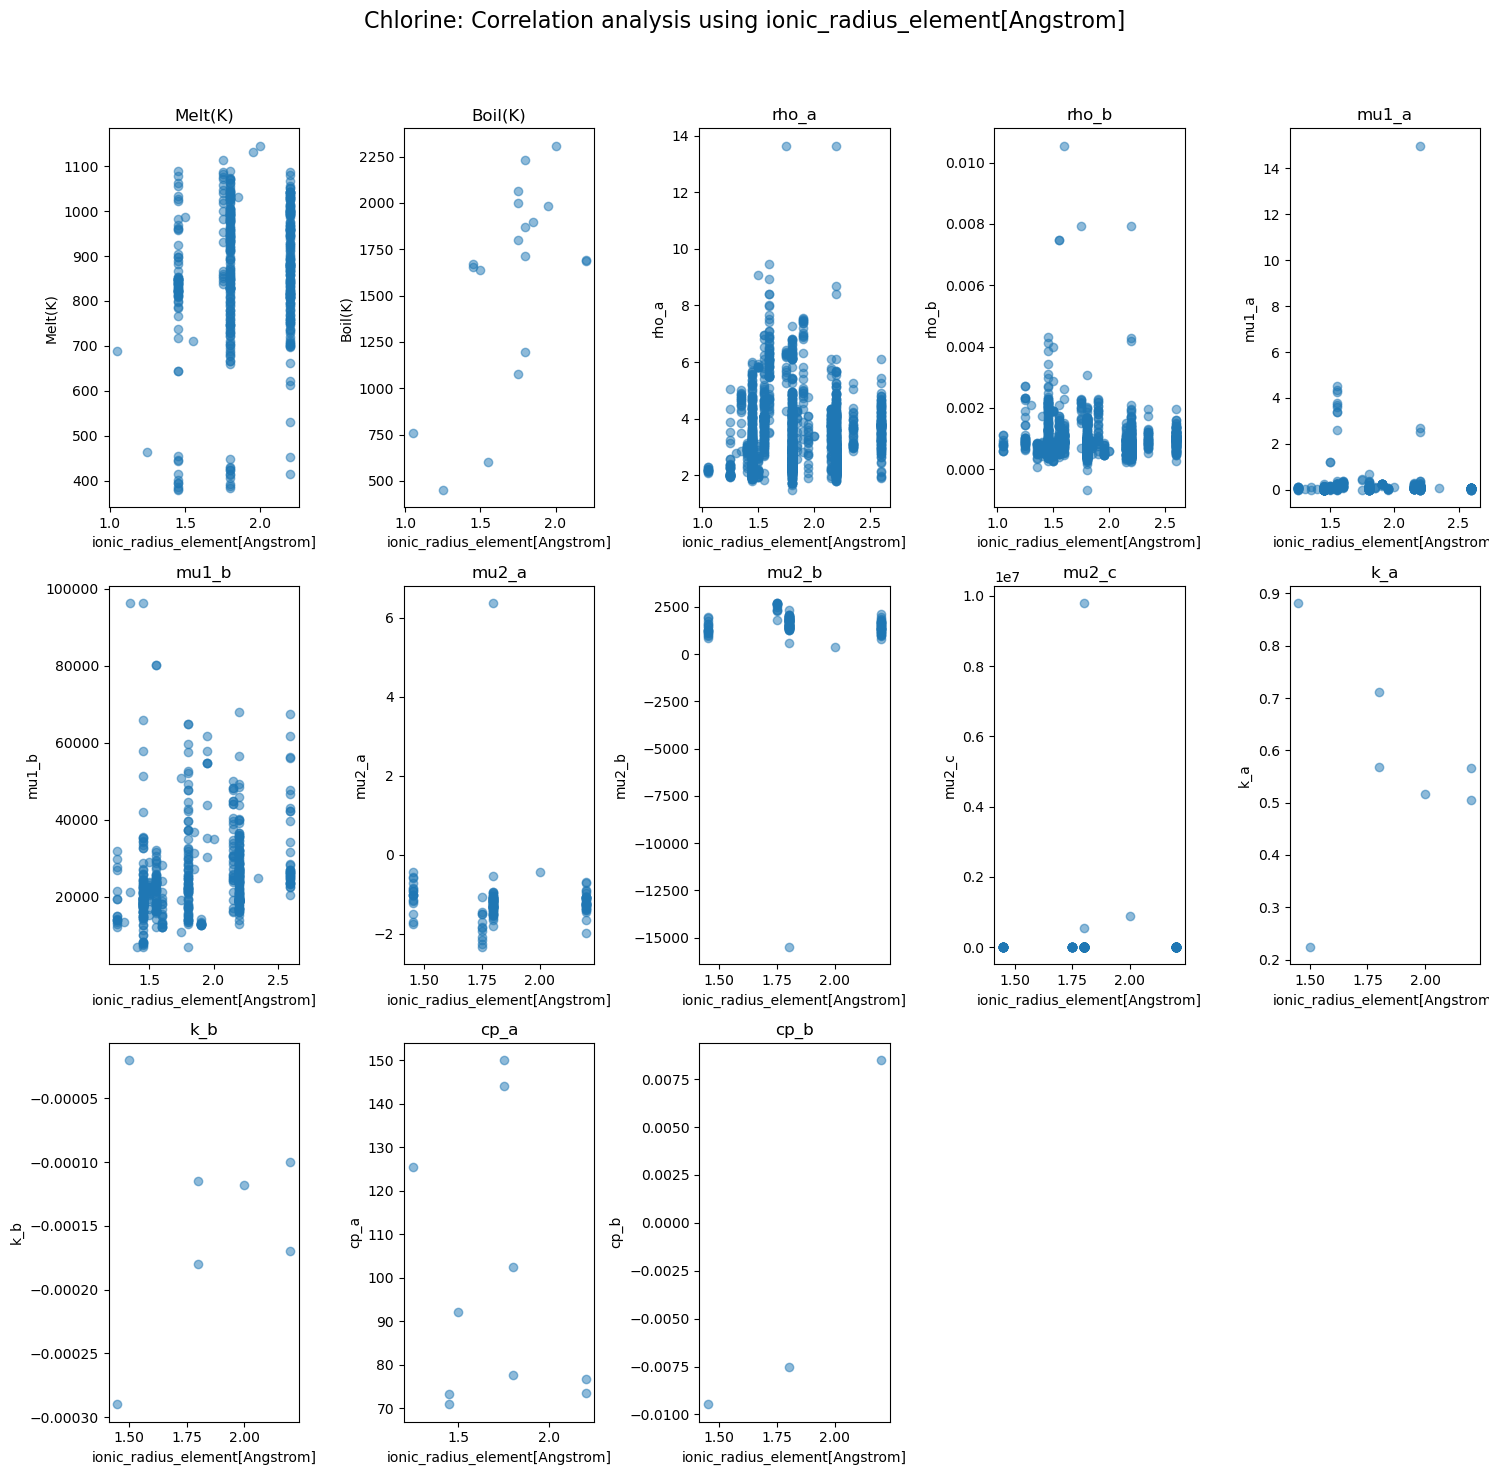

Correlation table:
         Correlation
Melt(K)     0.165154
Boil(K)     0.608950
rho_a      -0.065685
rho_b      -0.107056
mu1_a      -0.026990
mu1_b       0.249669
mu2_a      -0.027026
mu2_b      -0.019590
mu2_c      -0.019005
k_a        -0.116632
k_b         0.167179
cp_a       -0.206451
cp_b        0.926233

================ covalent_radius_element[Angstrom] ================



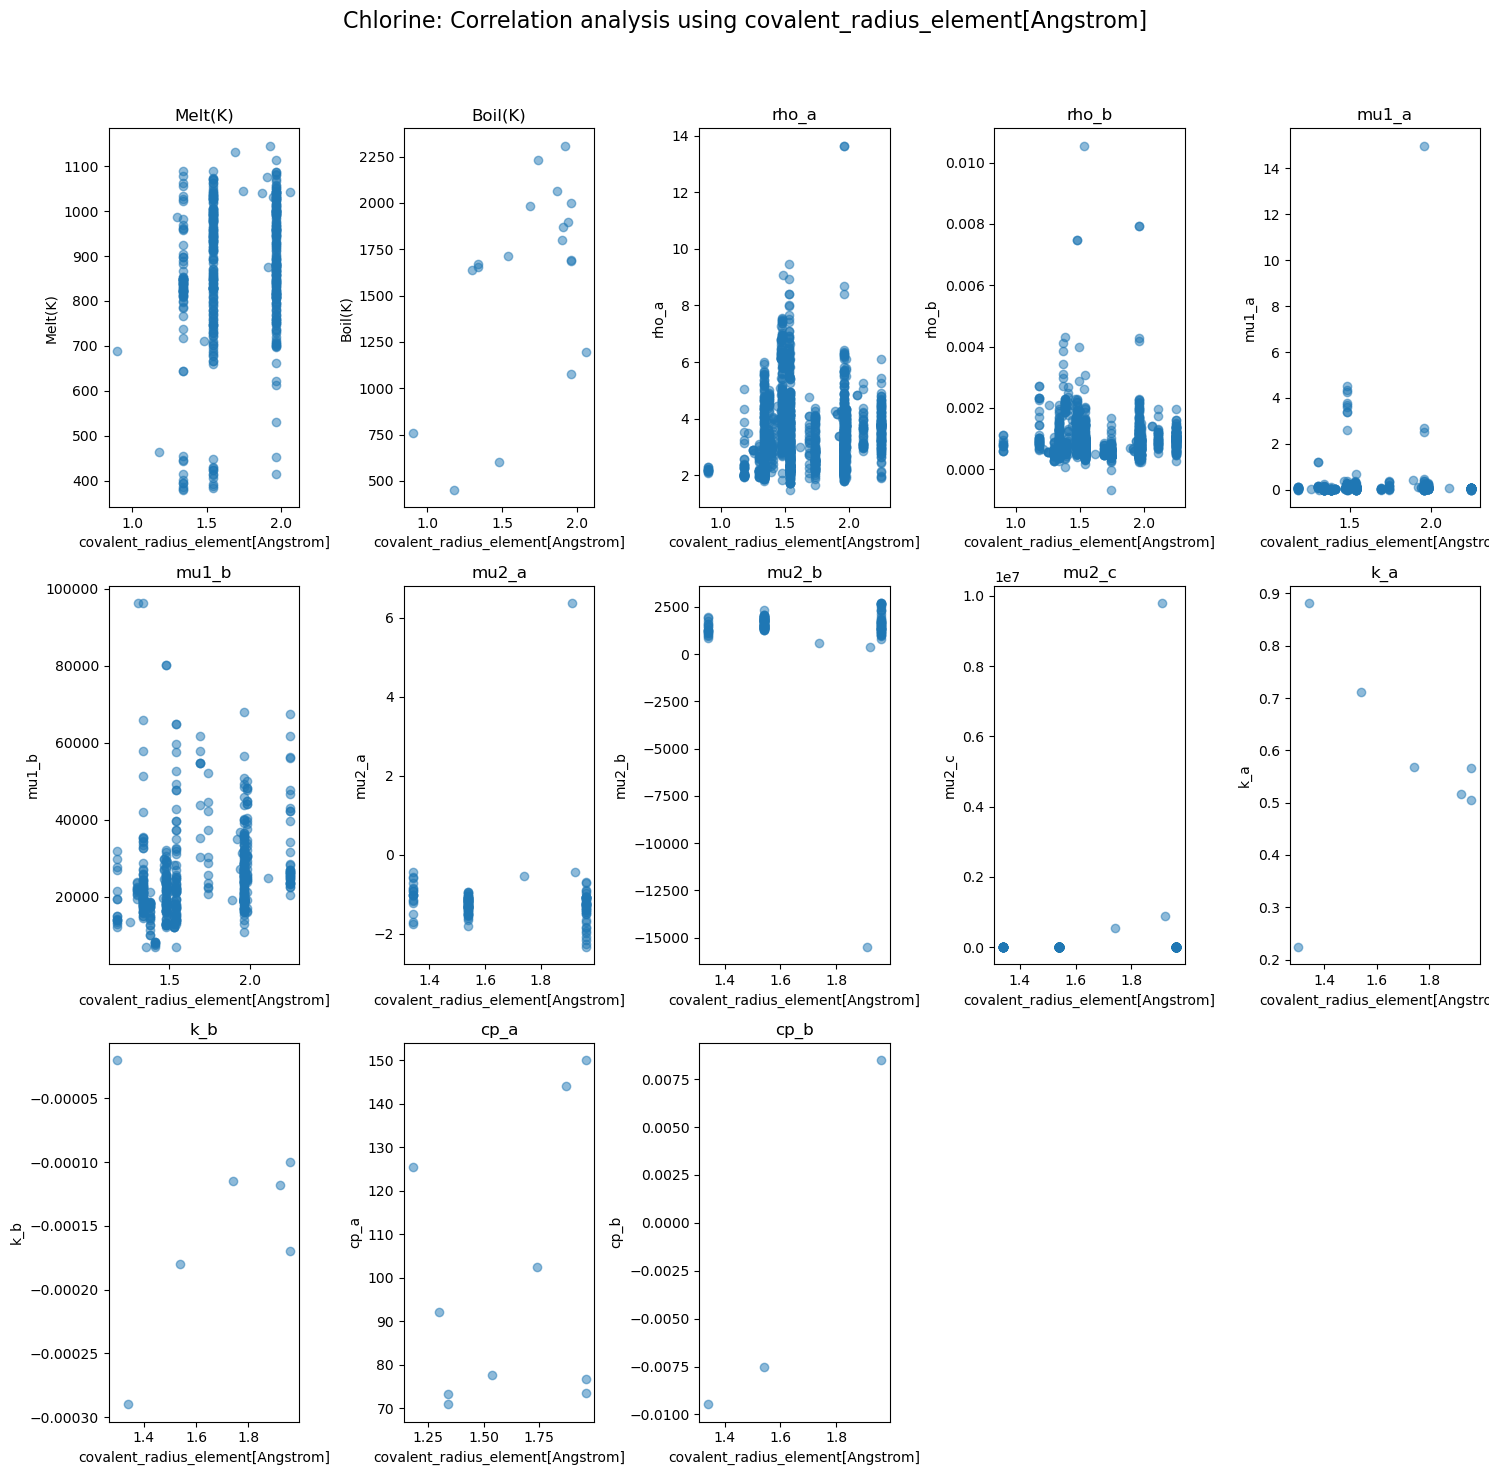

Correlation table:
         Correlation
Melt(K)     0.207976
Boil(K)     0.528388
rho_a      -0.042143
rho_b      -0.087420
mu1_a      -0.014452
mu1_b       0.254457
mu2_a      -0.025729
mu2_b      -0.039909
mu2_c       0.094157
k_a        -0.077088
k_b         0.142214
cp_a        0.232855
cp_b        0.975260

================ first_ionization_energy[kJ_per_mol] ================



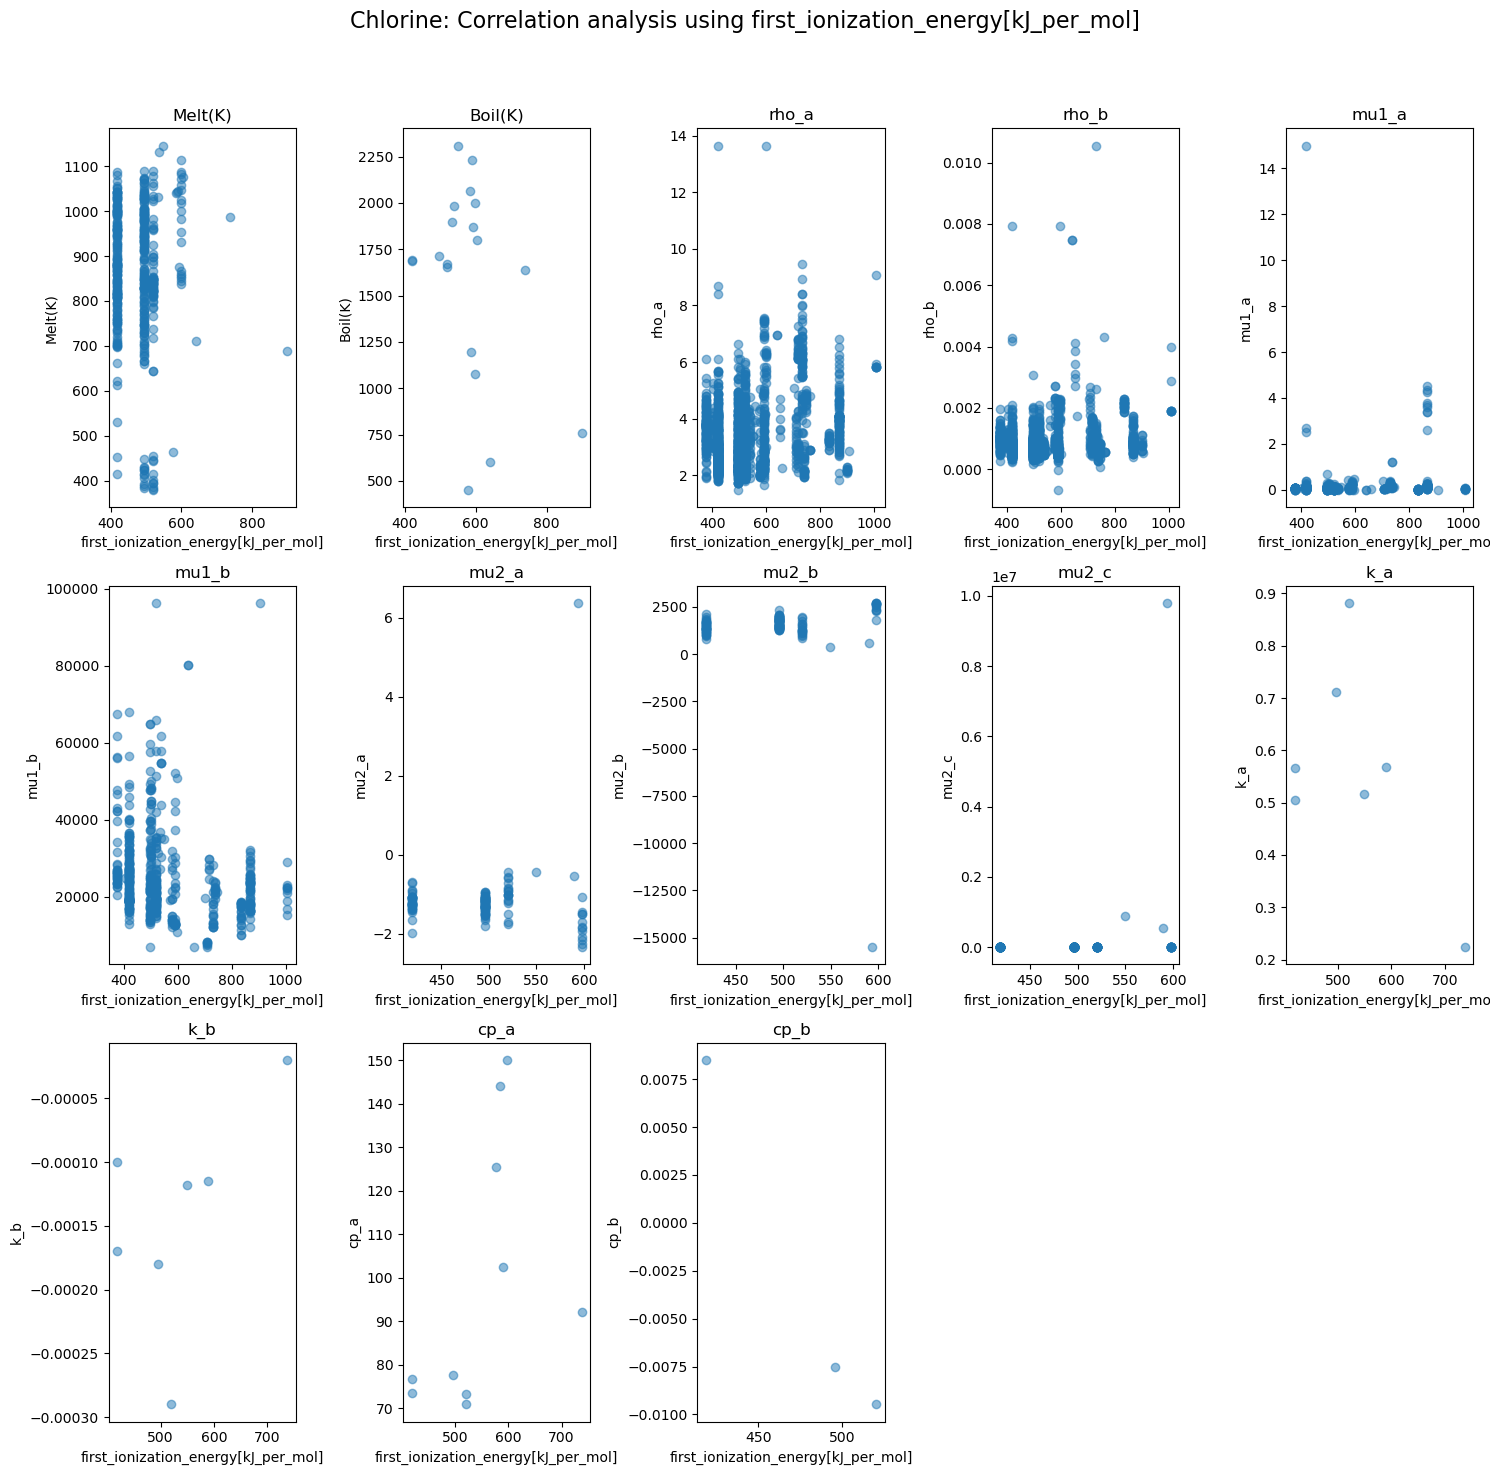

Correlation table:
         Correlation
Melt(K)    -0.034633
Boil(K)    -0.397454
rho_a       0.306320
rho_b       0.193854
mu1_a       0.105786
mu1_b      -0.224261
mu2_a       0.034586
mu2_b      -0.030515
mu2_c       0.185632
k_a        -0.548178
k_b         0.516100
cp_a        0.483250
cp_b       -0.991038

================ COMBINED CORRELATION MATRIX ================

        polarizability_element[10-24Cm3] atomic_mass_element  \
                             Correlation         Correlation   
Melt(K)                         0.171815            0.219048   
Boil(K)                         0.404710            0.174275   
rho_a                          -0.234156            0.531024   
rho_b                          -0.151213            0.325880   
mu1_a                          -0.067765            0.034361   
mu1_b                           0.313480           -0.003768   
mu2_a                          -0.151414           -0.092765   
mu2_b                           0.095356       

In [12]:

data_cols = [
    "polarizability_element[10-24Cm3]",
    "atomic_mass_element",
    "electronegativity_element",
    "atomic_radius_element[Angstrom]",
    "ionic_radius_element[Angstrom]",
    "covalent_radius_element[Angstrom]",
    "first_ionization_energy[kJ_per_mol]"
]

pred_cols = [
    "Melt(K)", "Boil(K)", "rho_a", "rho_b",
    "mu1_a", "mu1_b", "mu2_a", "mu2_b",
    "mu2_c", "k_a", "k_b", "cp_a", "cp_b"
]

tgt = data[pred_cols]

# =========================================================
# SAFE EVAL
# =========================================================
def safe_eval(x):
    if pd.isna(x):
        return np.nan
    try:
        value = ast.literal_eval(x)
        if not isinstance(value, dict):
            return np.nan

        cats = [k for k in value.keys() if k != "Cl"]
        if not cats:
            return np.nan

        return float(value[cats[0]])
    except Exception:
        return np.nan

# =========================================================
# CORRELATION ANALYSIS
# =========================================================
all_correlation_tables = {}

for atomic_col in data_cols:

    print(f"\n================ {atomic_col} ================\n")

    pred = data[atomic_col].apply(safe_eval)

    n_cols = 5
    n_rows = (len(tgt.columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    correlation_table = pd.DataFrame(
        index=tgt.columns,
        columns=["Correlation"],
        dtype=float
    )

    for i, target in enumerate(tgt.columns):

        mask = pred.notna() & tgt[target].notna()
        x = pred[mask]
        y = tgt[target][mask]

        if len(x) < 3:
            axes[i].set_title(f"{target}\n(insufficient data)")
            axes[i].axis("off")
            continue

        axes[i].scatter(x, y, alpha=0.5)
        axes[i].set_xlabel(atomic_col)
        axes[i].set_ylabel(target)
        axes[i].set_title(target)

        correlation_table.loc[target, "Correlation"] = x.corr(y)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # -------- TITLE --------
    fig.suptitle(
        f"Chlorine: Correlation analysis using {atomic_col}",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # -------- DISPLAY --------
    plt.show()

    # -------- SAVE --------
    safe_name = (
        atomic_col
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_")
        .replace(" ", "_")
    )

    file_path = os.path.join(
        output_dir,
        f"Chlorine: correlation_{safe_name}.png"
    )

    fig.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("Correlation table:")
    print(correlation_table)

    all_correlation_tables[atomic_col] = correlation_table

# =========================================================
# COMBINED CORRELATION MATRIX
# =========================================================
combined_correlation = pd.concat(all_correlation_tables, axis=1)

print("\n================ COMBINED CORRELATION MATRIX ================\n")
print(combined_correlation)


In [13]:
pred_cols = data.columns[3:16]
data_cols = data.columns[17:].drop('symbol')

anion_filter = 'F'
flag = data['System'].apply(lambda x: True if anion_filter in x else False)
data_clorine = data[flag]
data_clorine

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
88,KCl-KF,60.5649,0.15-0.85,NaN,NaN,2.5800,0.000676,NaN,NaN,NaN,...,"{'K': 0.82, 'Cl': 3.16, 'F': 3.98}","{'K': '1+', 'Cl': '1-', 'F': '1-'}","{'K': 2.43, 'Cl': 0.79, 'F': 0.42}","{'K': 2.2, 'Cl': 1.0, 'F': 0.5}","{'K': 1.96, 'Cl': 0.99, 'F': 0.71}","{'K': 418.8, 'Cl': 1251.2, 'F': 1681.0}","{'K': 'K', 'Cl': 'Cl', 'F': 'F'}",6.07,81.502969,20.375742
89,KCl-KF,61.3876,0.2-0.8,NaN,NaN,2.5500,0.000677,NaN,NaN,NaN,...,"{'K': 0.82, 'Cl': 3.16, 'F': 3.98}","{'K': '1+', 'Cl': '1-', 'F': '1-'}","{'K': 2.43, 'Cl': 0.79, 'F': 0.42}","{'K': 2.2, 'Cl': 1.0, 'F': 0.5}","{'K': 1.96, 'Cl': 0.99, 'F': 0.71}","{'K': 418.8, 'Cl': 1251.2, 'F': 1681.0}","{'K': 'K', 'Cl': 'Cl', 'F': 'F'}",6.07,81.502969,20.375742
90,KCl-KF,62.2104,0.25-0.75,NaN,NaN,2.4679,0.000633,NaN,NaN,NaN,...,"{'K': 0.82, 'Cl': 3.16, 'F': 3.98}","{'K': '1+', 'Cl': '1-', 'F': '1-'}","{'K': 2.43, 'Cl': 0.79, 'F': 0.42}","{'K': 2.2, 'Cl': 1.0, 'F': 0.5}","{'K': 1.96, 'Cl': 0.99, 'F': 0.71}","{'K': 418.8, 'Cl': 1251.2, 'F': 1681.0}","{'K': 'K', 'Cl': 'Cl', 'F': 'F'}",6.07,81.502969,20.375742
91,KCl-KF,64.6785,0.4-0.6,NaN,NaN,2.3804,0.000619,NaN,NaN,NaN,...,"{'K': 0.82, 'Cl': 3.16, 'F': 3.98}","{'K': '1+', 'Cl': '1-', 'F': '1-'}","{'K': 2.43, 'Cl': 0.79, 'F': 0.42}","{'K': 2.2, 'Cl': 1.0, 'F': 0.5}","{'K': 1.96, 'Cl': 0.99, 'F': 0.71}","{'K': 418.8, 'Cl': 1251.2, 'F': 1681.0}","{'K': 'K', 'Cl': 'Cl', 'F': 'F'}",6.07,81.502969,20.375742
92,KCl-KF,66.3240,0.5-0.5,NaN,NaN,2.3369,0.000624,NaN,NaN,NaN,...,"{'K': 0.82, 'Cl': 3.16, 'F': 3.98}","{'K': '1+', 'Cl': '1-', 'F': '1-'}","{'K': 2.43, 'Cl': 0.79, 'F': 0.42}","{'K': 2.2, 'Cl': 1.0, 'F': 0.5}","{'K': 1.96, 'Cl': 0.99, 'F': 0.71}","{'K': 418.8, 'Cl': 1251.2, 'F': 1681.0}","{'K': 'K', 'Cl': 'Cl', 'F': 'F'}",6.07,81.502969,20.375742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4179,NaCl-NaF,NaN,0.25-0.75,NaN,NaN,1.8140,NaN,NaN,NaN,NaN,...,"{'Na': 0.93, 'Cl': 3.16, 'F': 3.98}","{'Na': '1+', 'Cl': '1-', 'F': '1-'}","{'Na': 1.9, 'Cl': 0.79, 'F': 0.42}","{'Na': 1.8, 'Cl': 1.0, 'F': 0.5}","{'Na': 1.54, 'Cl': 0.99, 'F': 0.71}","{'Na': 495.8, 'Cl': 1251.2, 'F': 1681.0}","{'Na': 'Na', 'Cl': 'Cl', 'F': 'F'}",5.01,42.827080,10.706770
4180,NaCl-NaF,NaN,0.3-0.7,NaN,NaN,1.7160,NaN,NaN,NaN,NaN,...,"{'Na': 0.93, 'Cl': 3.16, 'F': 3.98}","{'Na': '1+', 'Cl': '1-', 'F': '1-'}","{'Na': 1.9, 'Cl': 0.79, 'F': 0.42}","{'Na': 1.8, 'Cl': 1.0, 'F': 0.5}","{'Na': 1.54, 'Cl': 0.99, 'F': 0.71}","{'Na': 495.8, 'Cl': 1251.2, 'F': 1681.0}","{'Na': 'Na', 'Cl': 'Cl', 'F': 'F'}",5.01,42.827080,10.706770
4181,NaCl-NaF,NaN,0.5-0.5,NaN,NaN,1.8720,0.000178,NaN,NaN,NaN,...,"{'Na': 0.93, 'Cl': 3.16, 'F': 3.98}","{'Na': '1+', 'Cl': '1-', 'F': '1-'}","{'Na': 1.9, 'Cl': 0.79, 'F': 0.42}","{'Na': 1.8, 'Cl': 1.0, 'F': 0.5}","{'Na': 1.54, 'Cl': 0.99, 'F': 0.71}","{'Na': 495.8, 'Cl': 1251.2, 'F': 1681.0}","{'Na': 'Na', 'Cl': 'Cl', 'F': 'F'}",5.01,42.827080,10.706770
4182,NaCl-NaF,NaN,0.75-0.25,NaN,NaN,2.3460,0.000664,NaN,NaN,NaN,...,"{'Na': 0.93, 'Cl': 3.16, 'F': 3.98}","{'Na': '1+', 'Cl': '1-', 'F': '1-'}","{'Na': 1.9, 'Cl': 0.79, 'F': 0.42}","{'Na': 1.8, 'Cl': 1.0, 'F': 0.5}","{'Na': 1.54, 'Cl': 0.99, 'F': 0.71}","{'Na': 495.8, 'Cl': 1251.2, 'F': 1681.0}","{'Na': 'Na', 'Cl': 'Cl', 'F': 'F'}",5.01,42.827080,10.706770



================ polarizability_element[10-24Cm3] ================



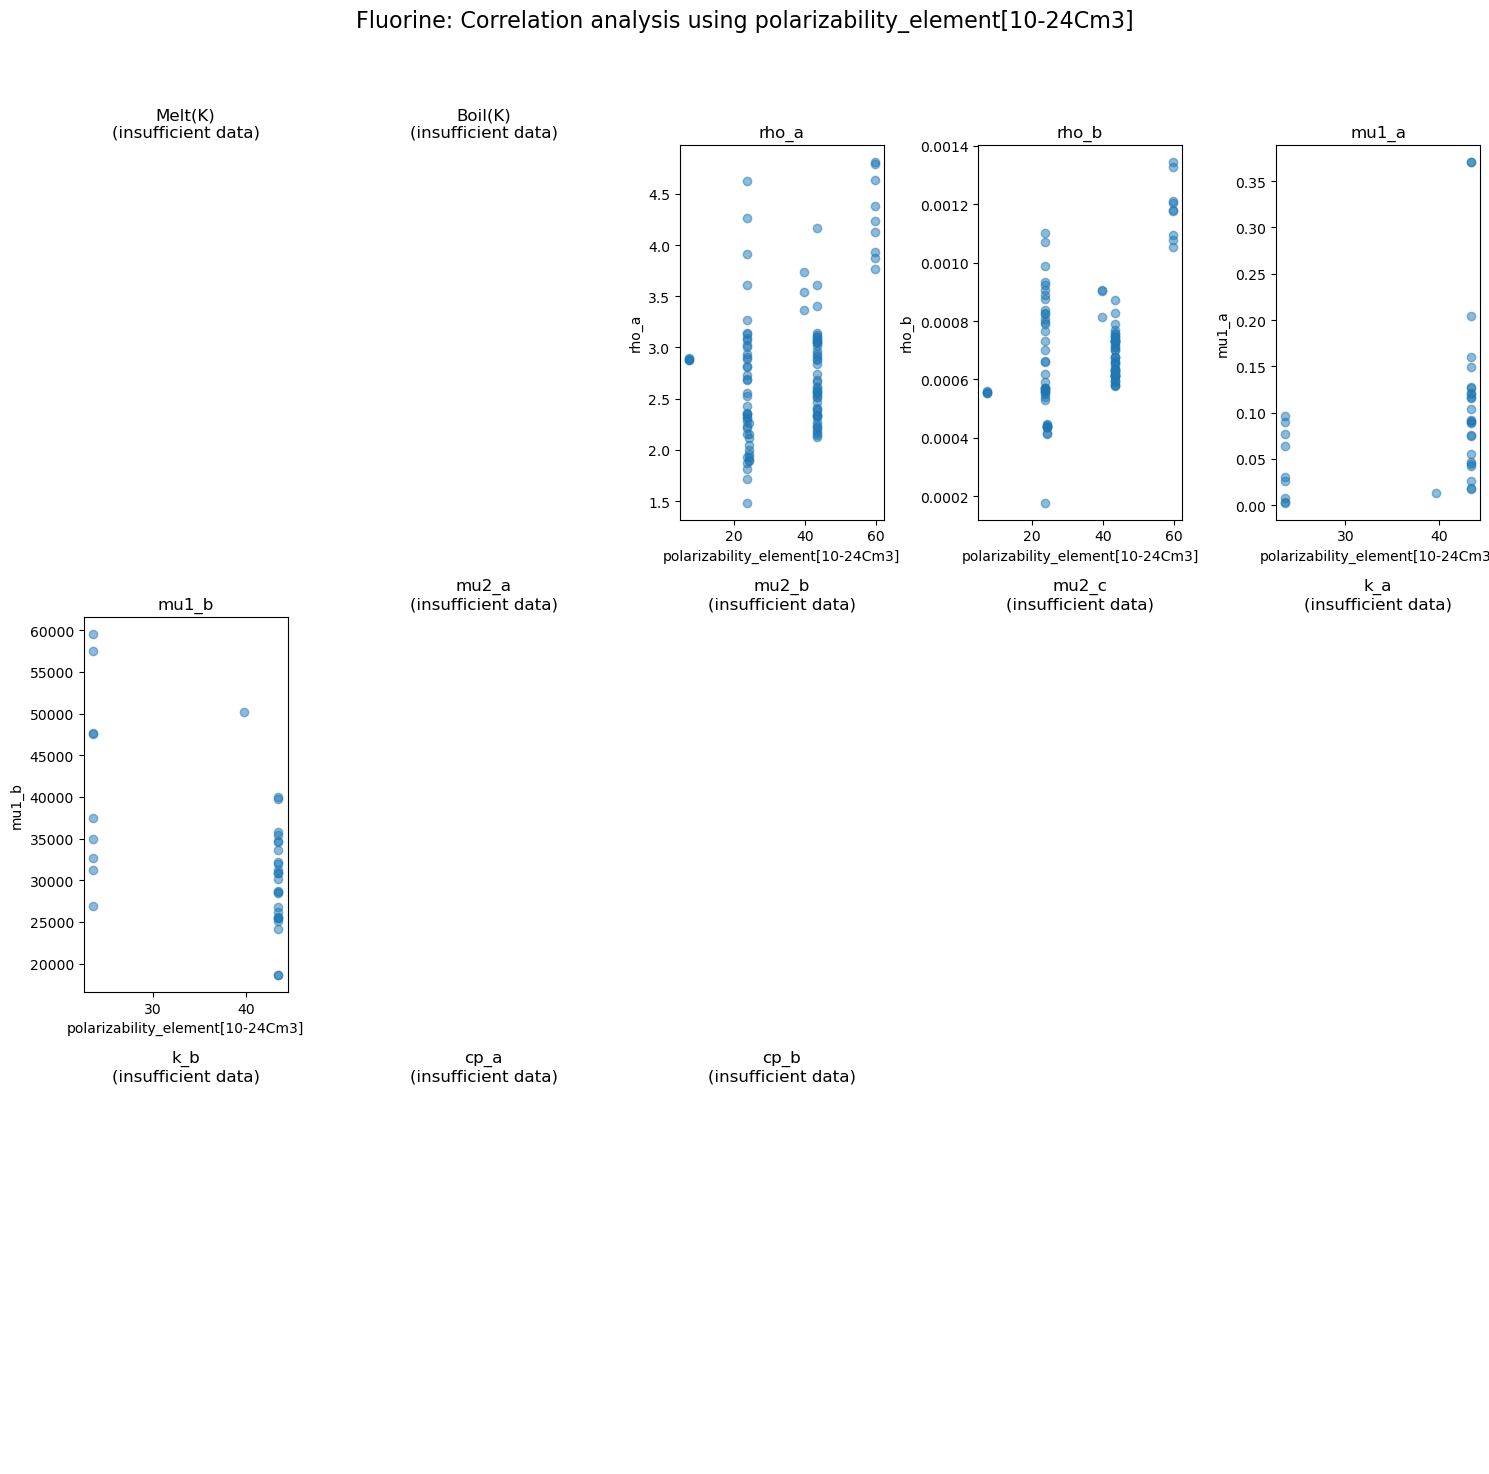

Correlation table:
         Correlation
Melt(K)          NaN
Boil(K)          NaN
rho_a       0.420691
rho_b       0.492112
mu1_a       0.359243
mu1_b      -0.546552
mu2_a            NaN
mu2_b            NaN
mu2_c            NaN
k_a              NaN
k_b              NaN
cp_a             NaN
cp_b             NaN

================ atomic_mass_element ================



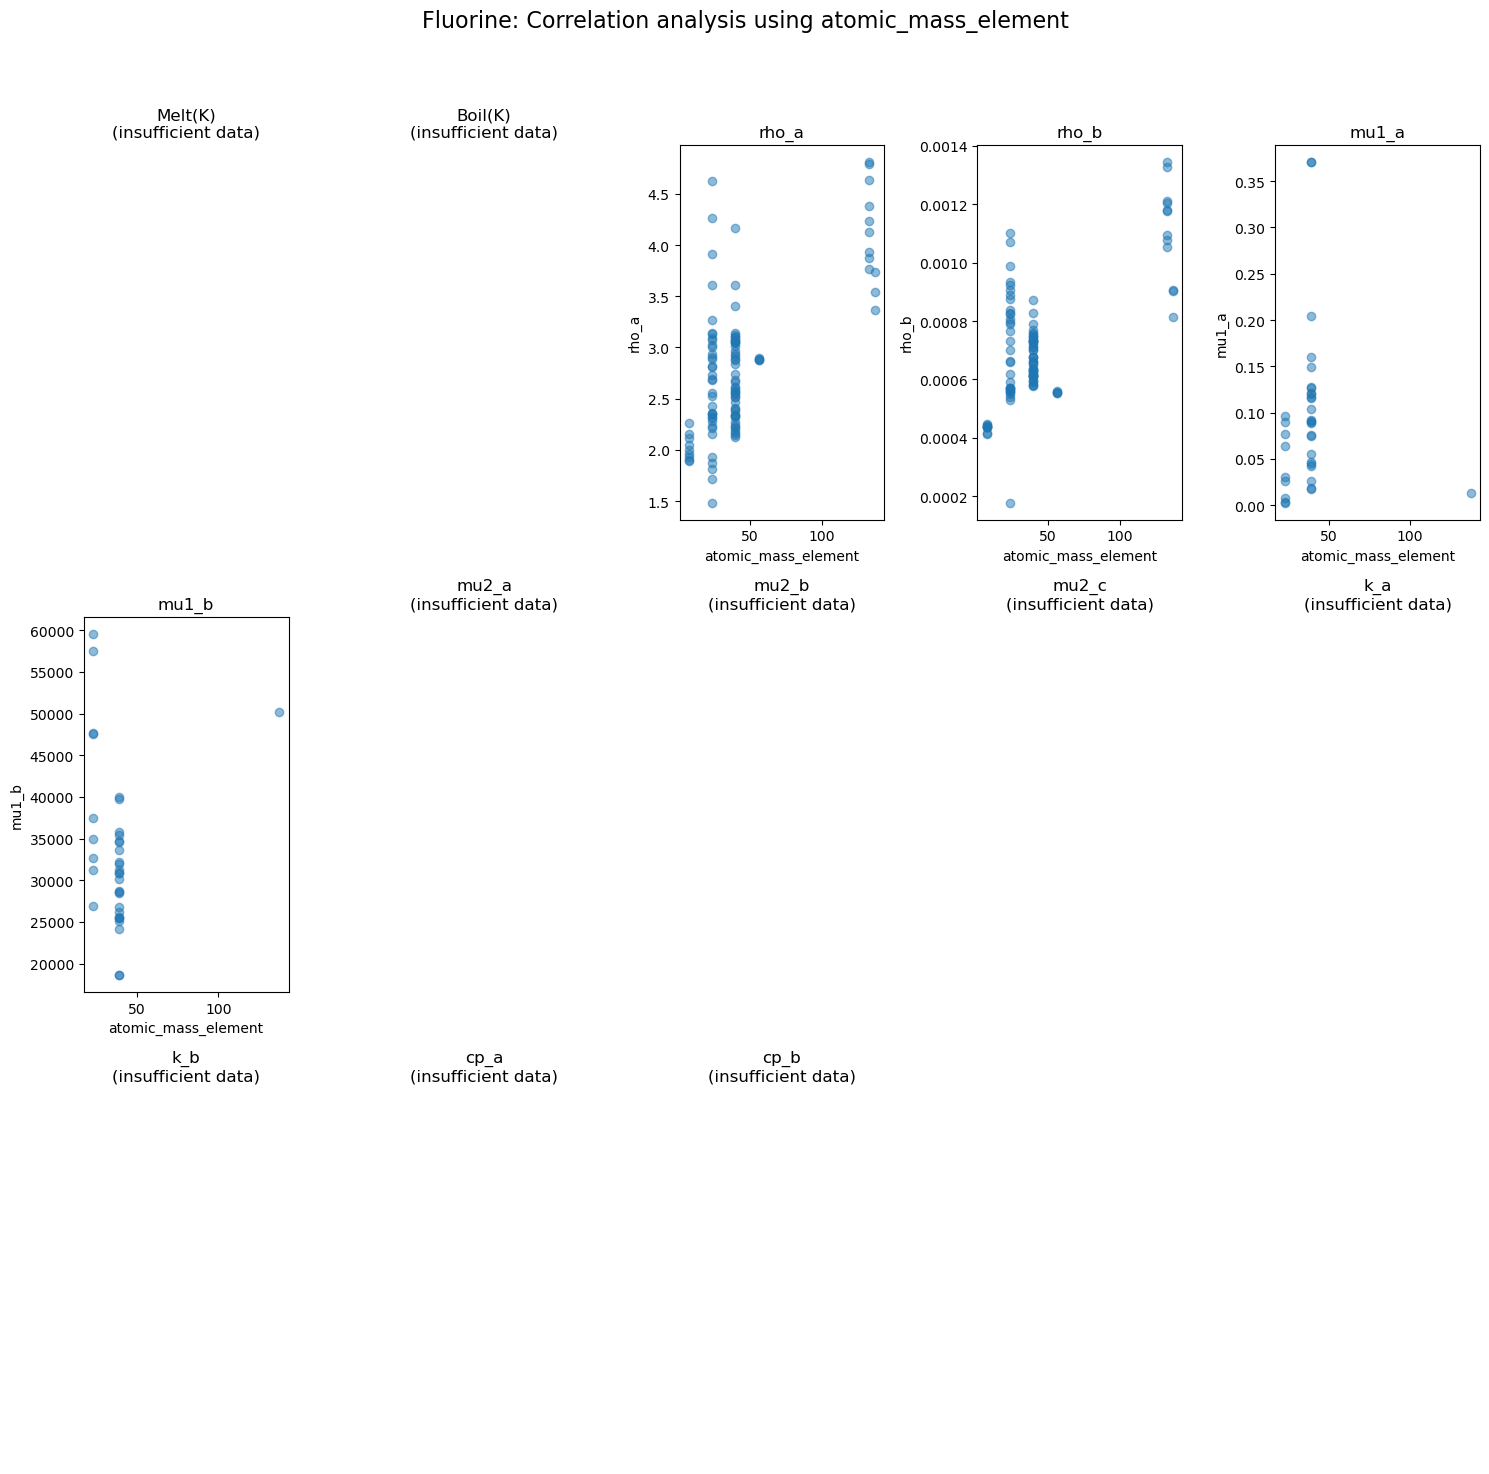

Correlation table:
         Correlation
Melt(K)          NaN
Boil(K)          NaN
rho_a       0.673736
rho_b       0.687985
mu1_a      -0.013347
mu1_b       0.071962
mu2_a            NaN
mu2_b            NaN
mu2_c            NaN
k_a              NaN
k_b              NaN
cp_a             NaN
cp_b             NaN

================ electronegativity_element ================



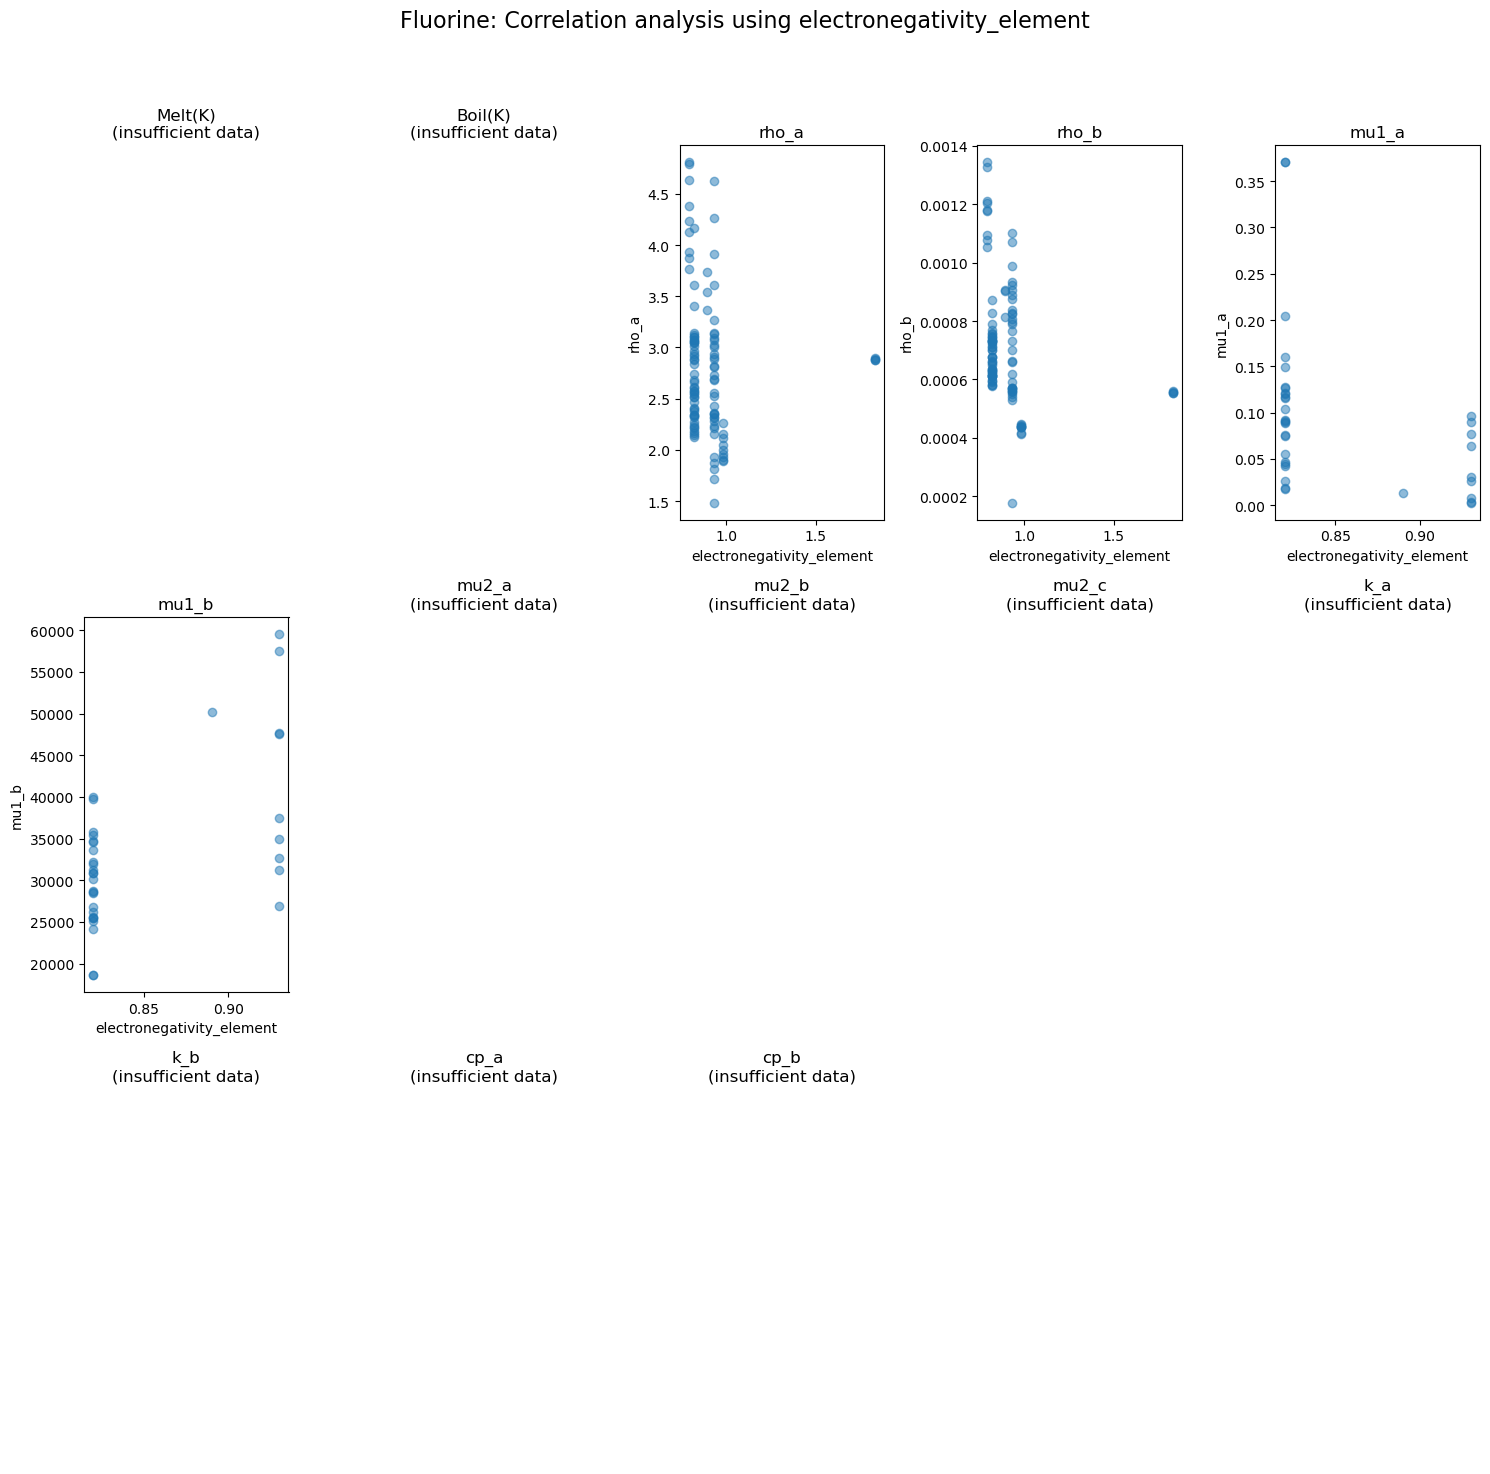

Correlation table:
         Correlation
Melt(K)          NaN
Boil(K)          NaN
rho_a      -0.103780
rho_b      -0.268337
mu1_a      -0.383751
mu1_b       0.593475
mu2_a            NaN
mu2_b            NaN
mu2_c            NaN
k_a              NaN
k_b              NaN
cp_a             NaN
cp_b             NaN

================ atomic_radius_element[Angstrom] ================



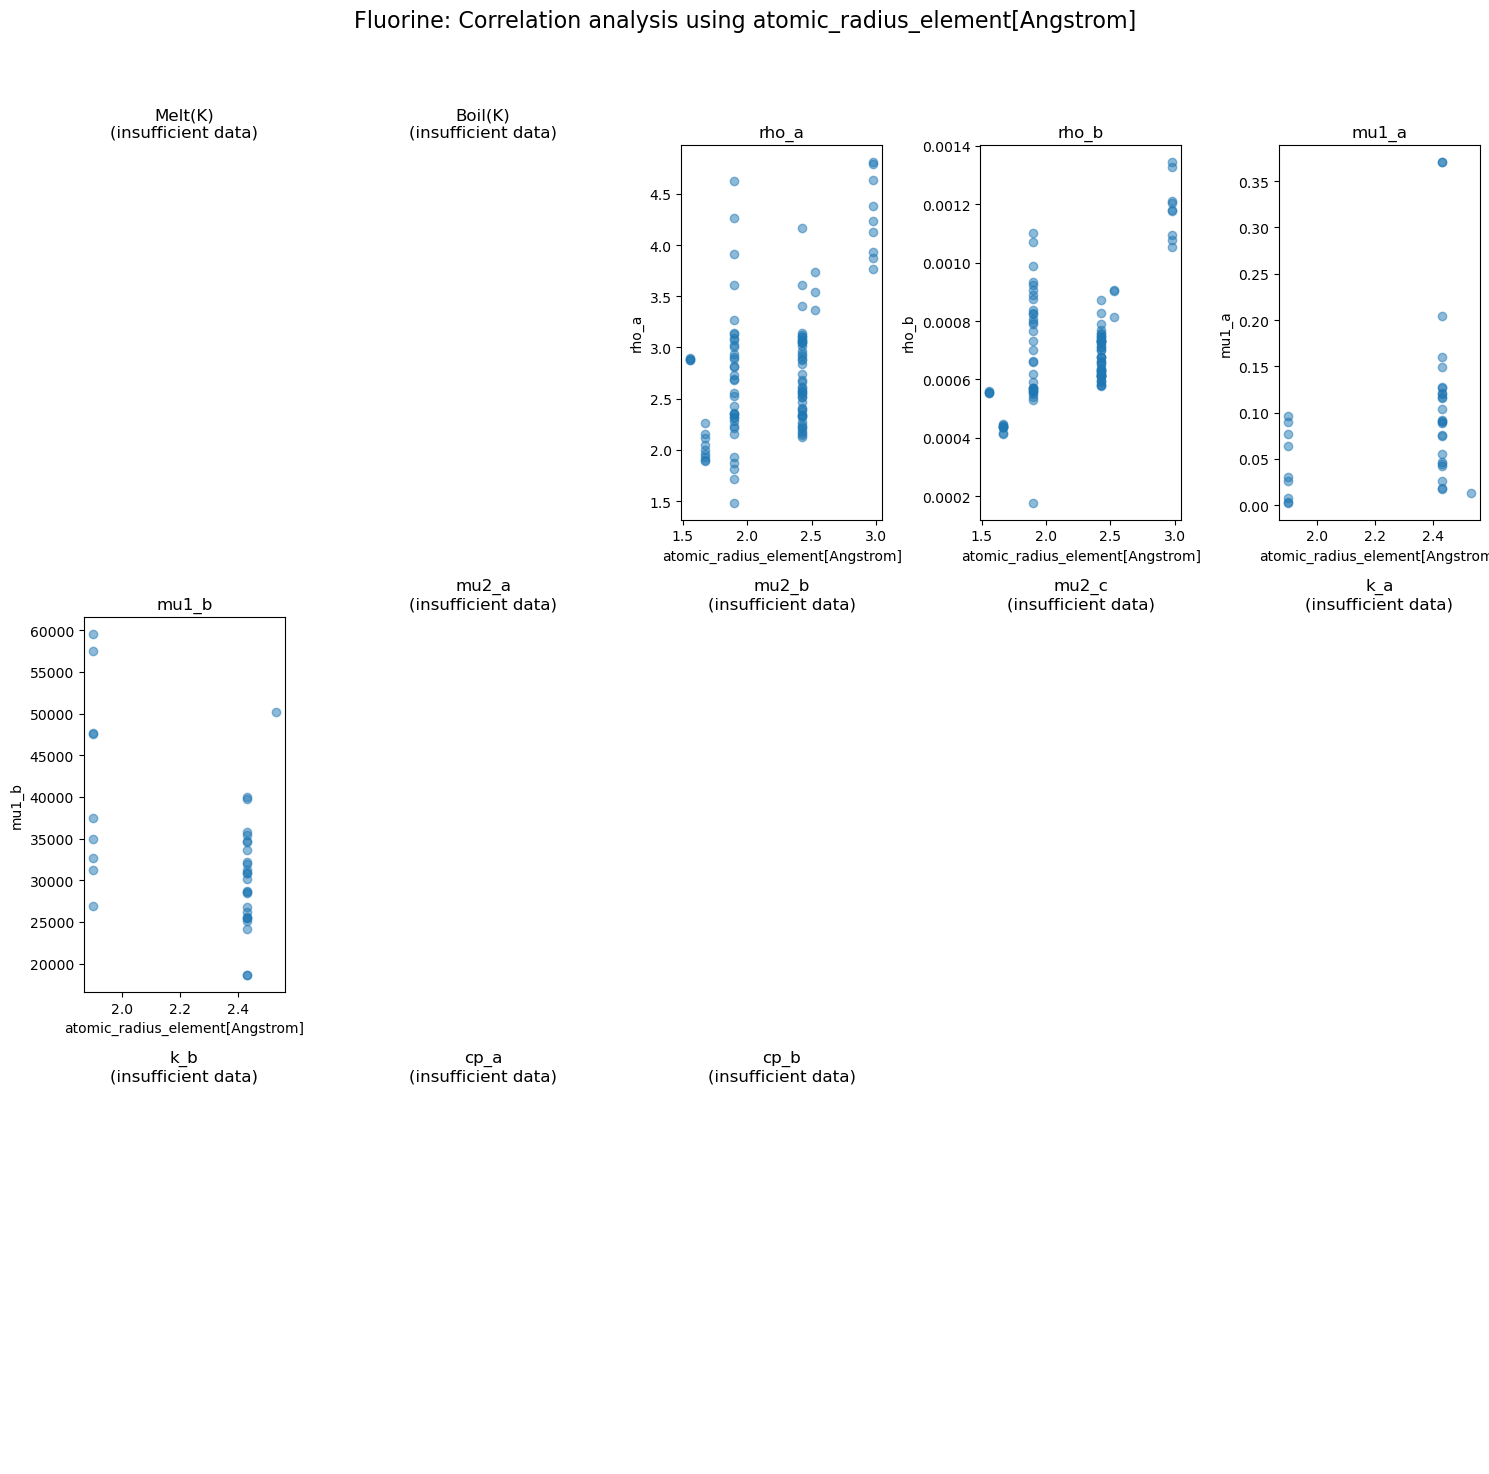

Correlation table:
         Correlation
Melt(K)          NaN
Boil(K)          NaN
rho_a       0.506758
rho_b       0.580094
mu1_a       0.330871
mu1_b      -0.495374
mu2_a            NaN
mu2_b            NaN
mu2_c            NaN
k_a              NaN
k_b              NaN
cp_a             NaN
cp_b             NaN

================ ionic_radius_element[Angstrom] ================



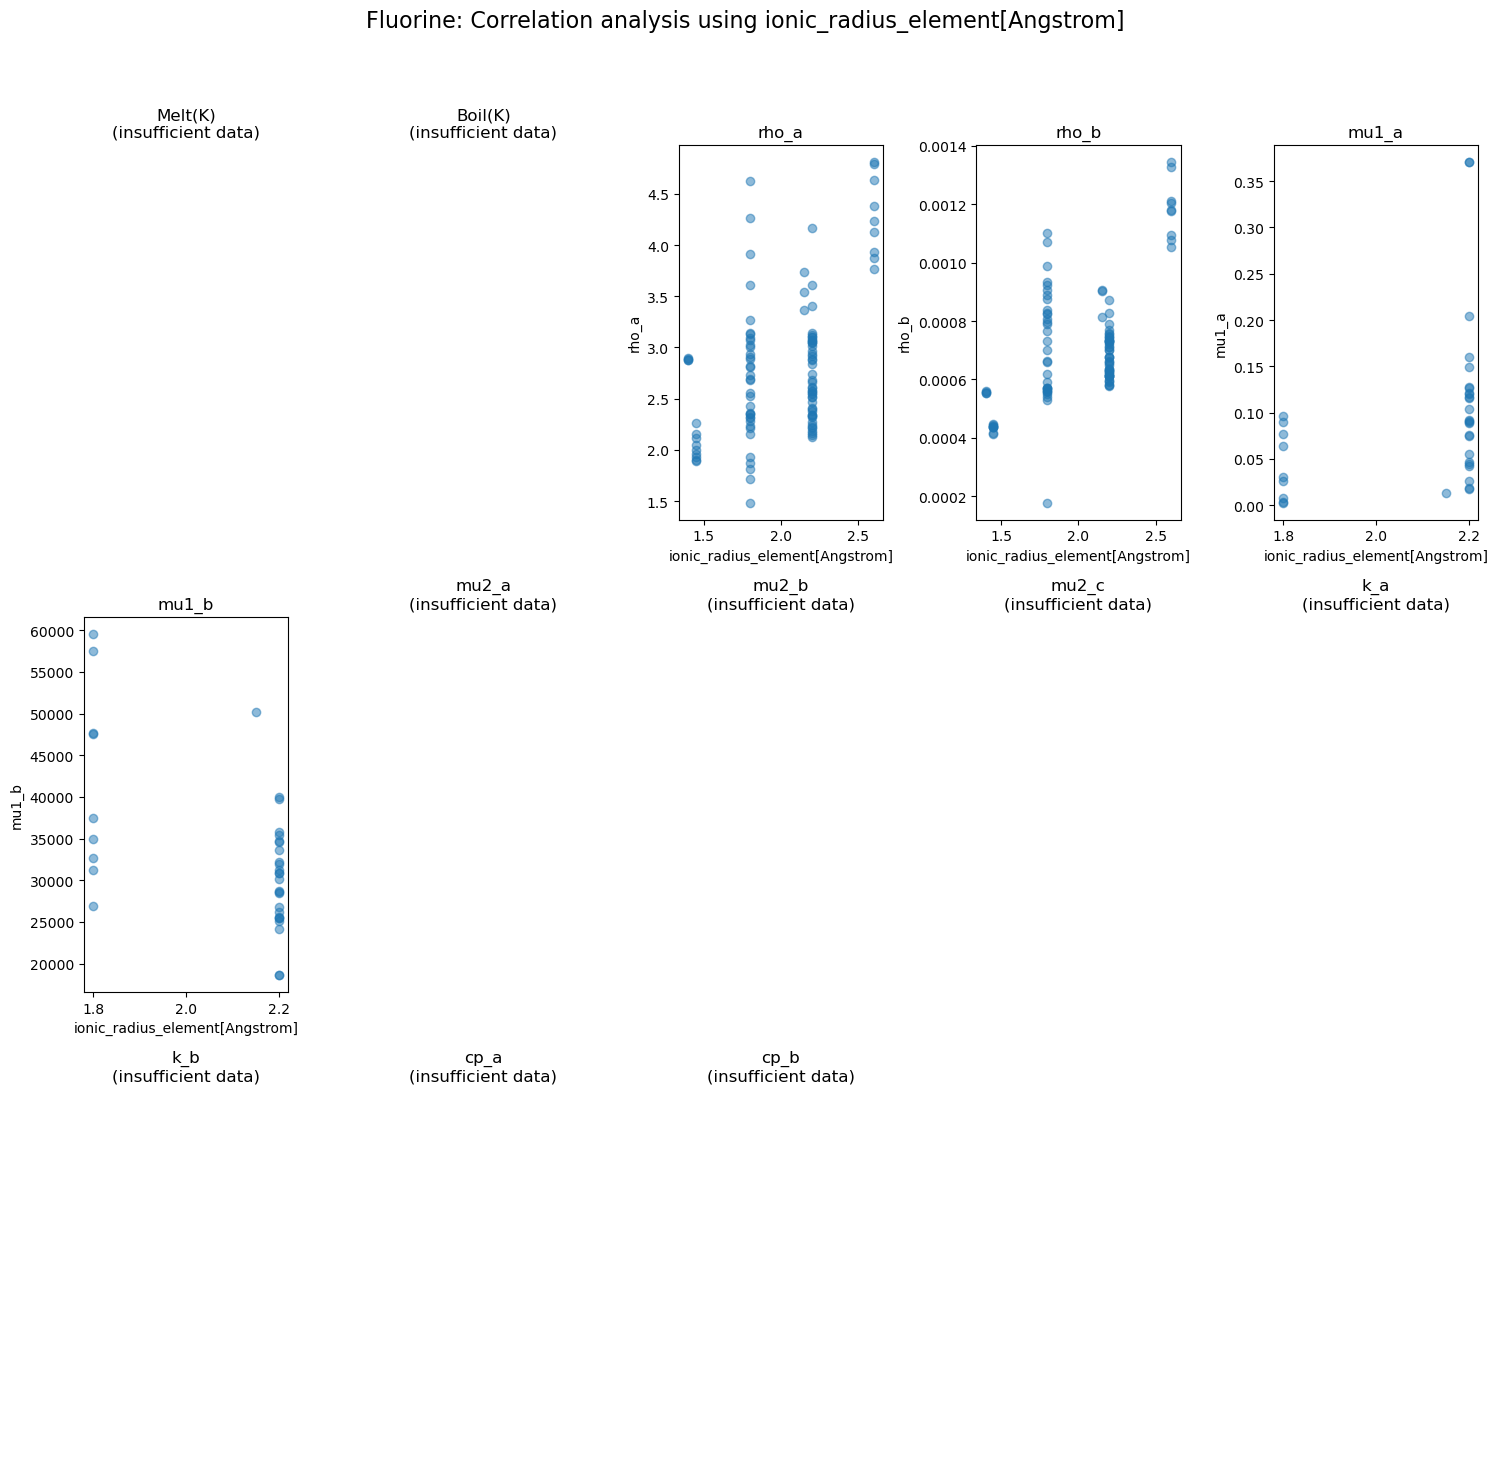

Correlation table:
         Correlation
Melt(K)          NaN
Boil(K)          NaN
rho_a       0.491701
rho_b       0.586274
mu1_a       0.355010
mu1_b      -0.538774
mu2_a            NaN
mu2_b            NaN
mu2_c            NaN
k_a              NaN
k_b              NaN
cp_a             NaN
cp_b             NaN

================ covalent_radius_element[Angstrom] ================



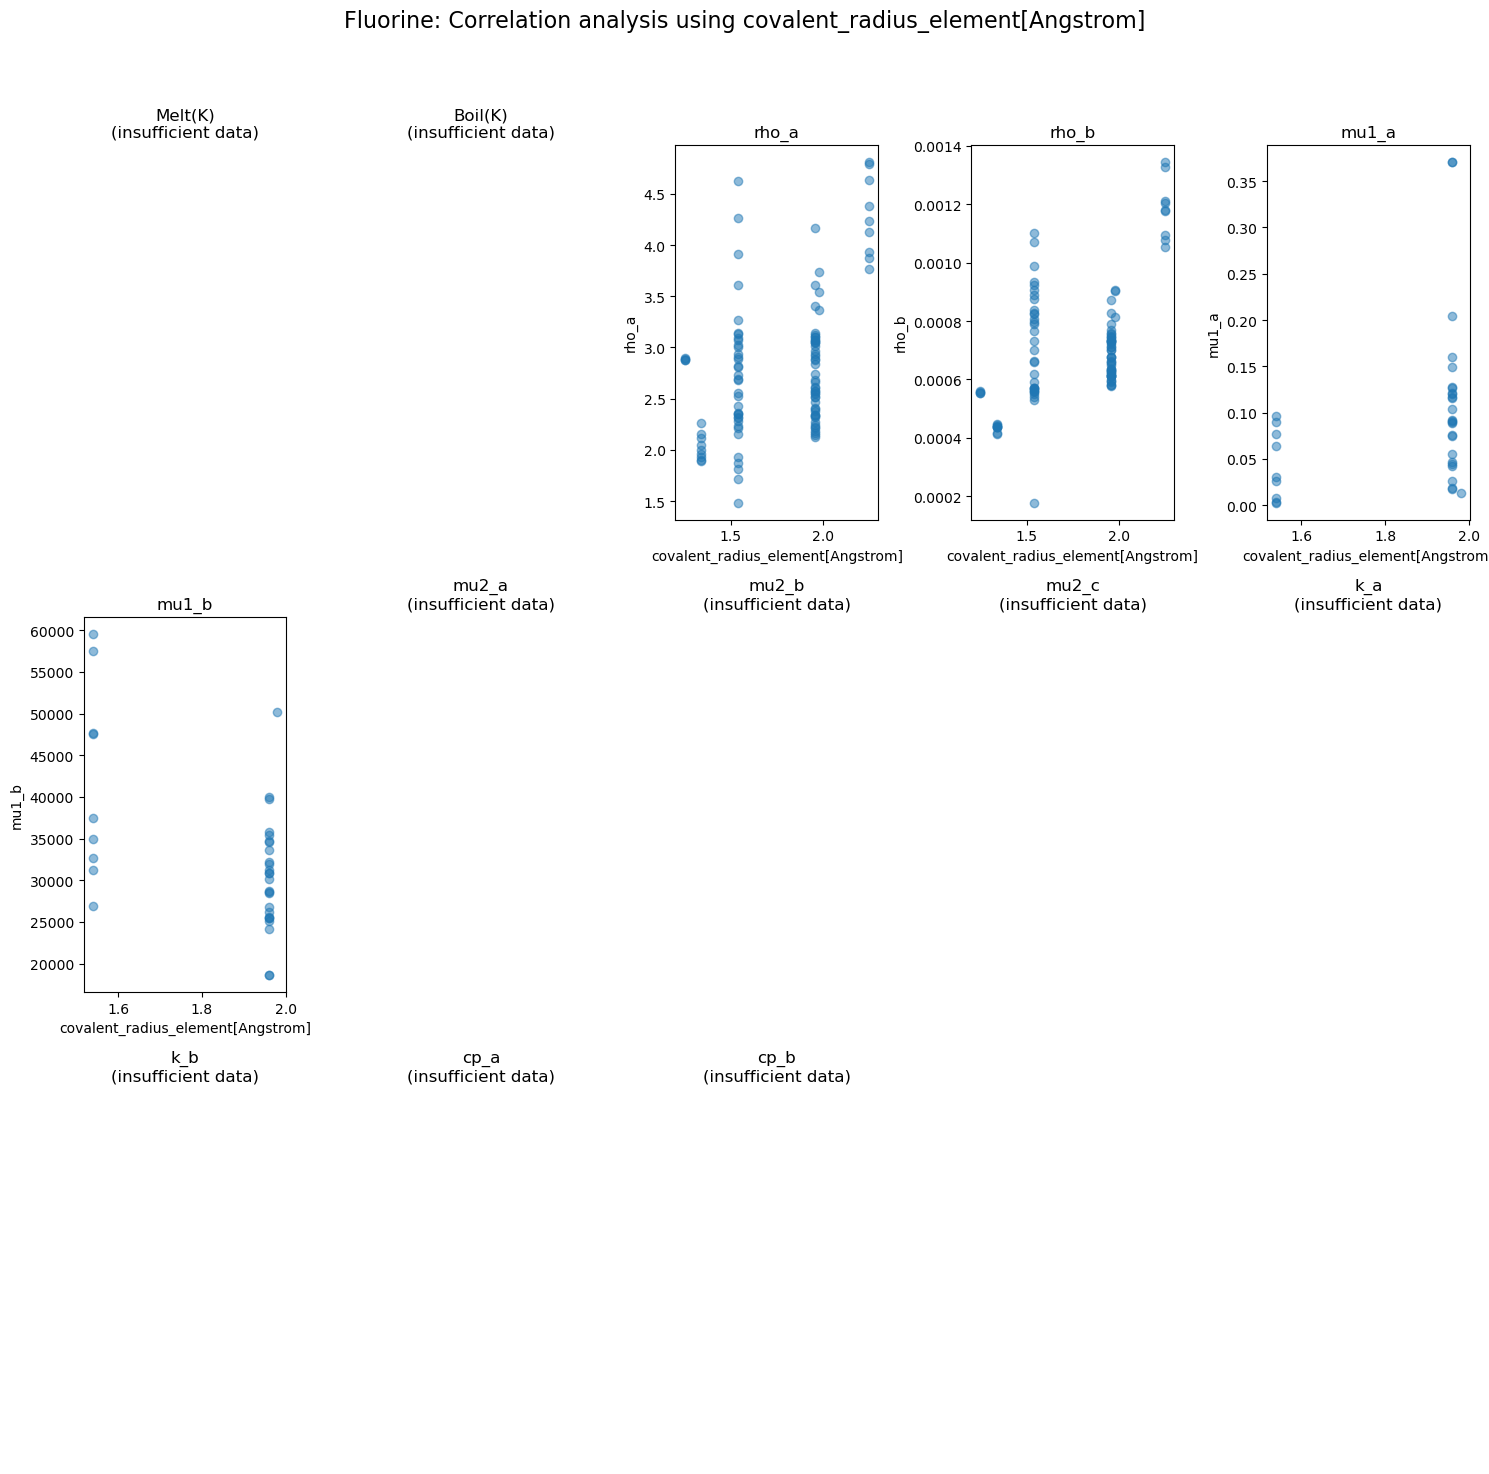

Correlation table:
         Correlation
Melt(K)          NaN
Boil(K)          NaN
rho_a       0.453036
rho_b       0.526044
mu1_a       0.342240
mu1_b      -0.515641
mu2_a            NaN
mu2_b            NaN
mu2_c            NaN
k_a              NaN
k_b              NaN
cp_a             NaN
cp_b             NaN

================ first_ionization_energy[kJ_per_mol] ================



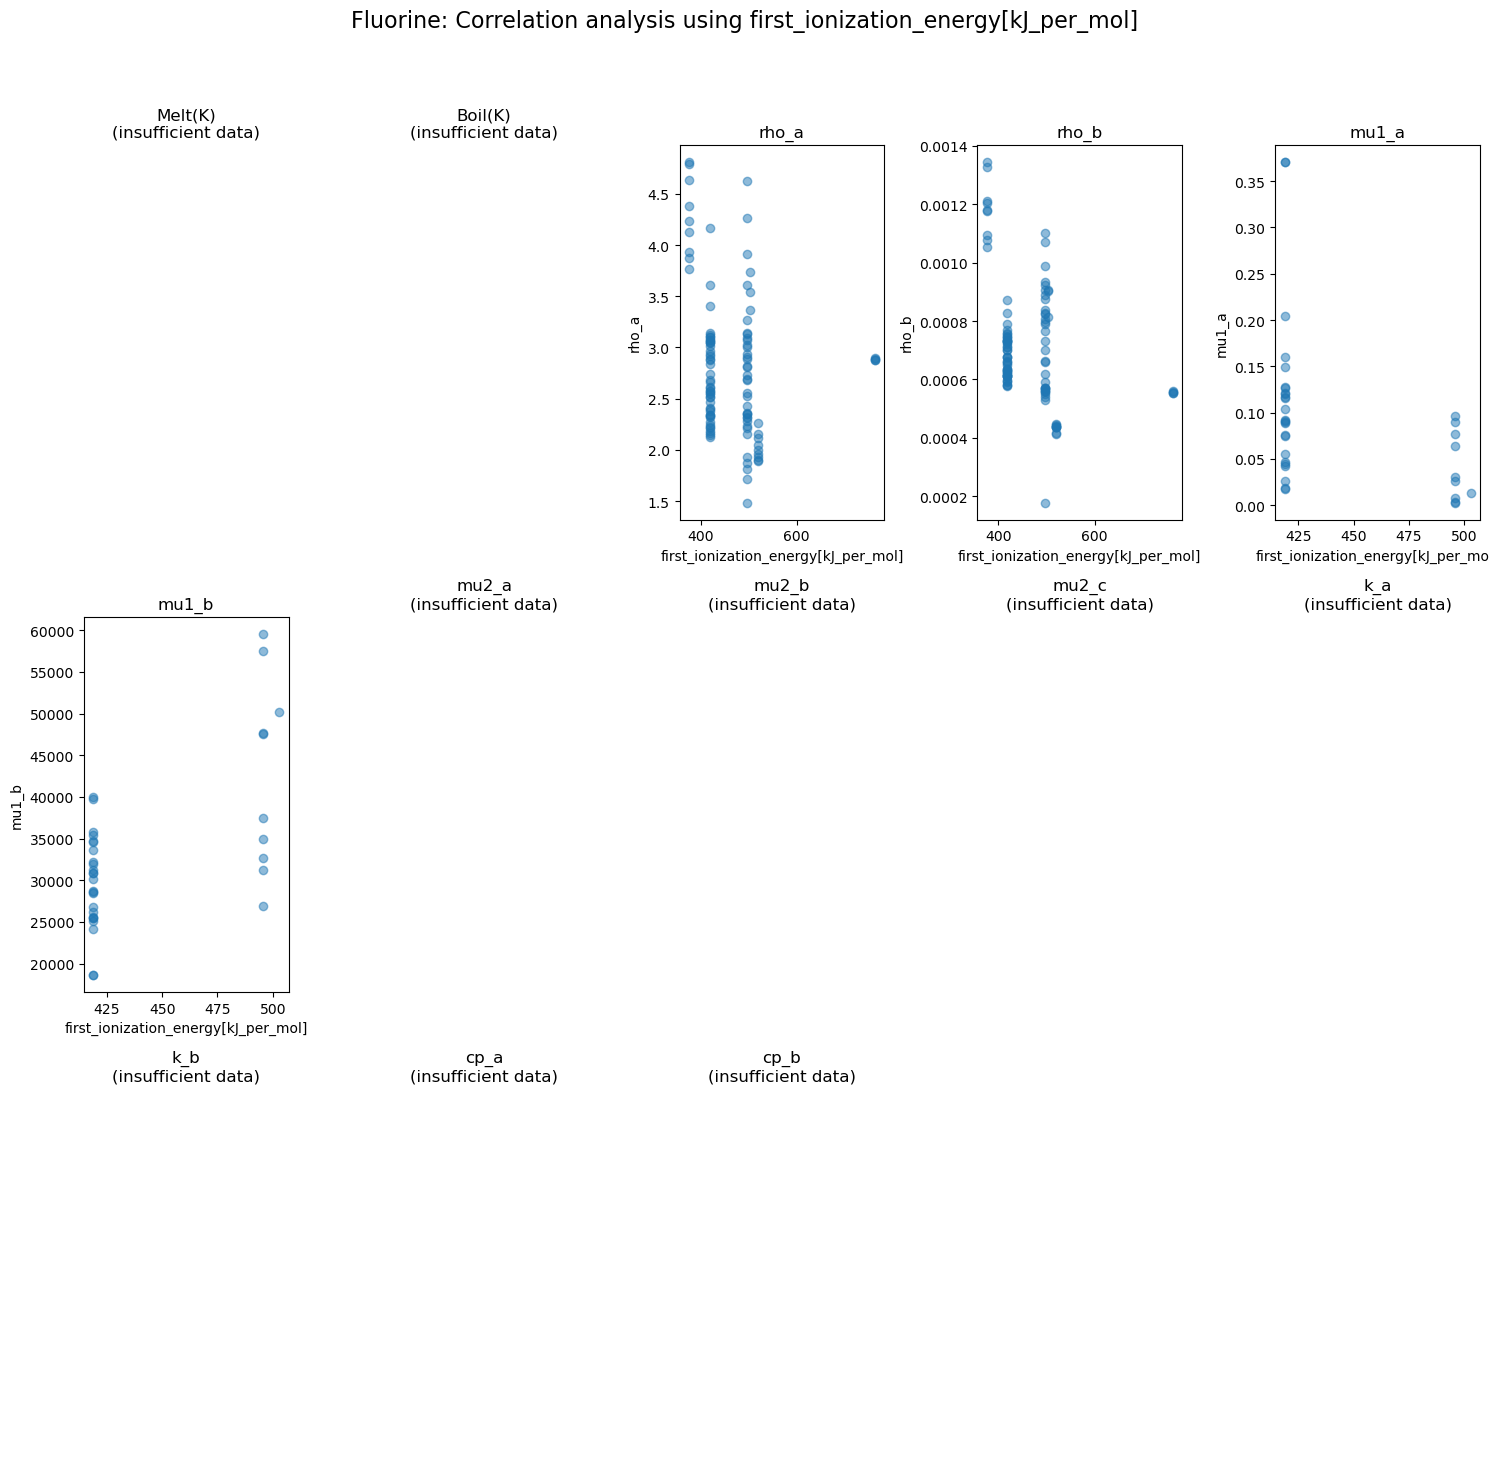

Correlation table:
         Correlation
Melt(K)          NaN
Boil(K)          NaN
rho_a      -0.231180
rho_b      -0.375463
mu1_a      -0.396775
mu1_b       0.622343
mu2_a            NaN
mu2_b            NaN
mu2_c            NaN
k_a              NaN
k_b              NaN
cp_a             NaN
cp_b             NaN

================ COMBINED CORRELATION MATRIX ================

        polarizability_element[10-24Cm3] atomic_mass_element  \
                             Correlation         Correlation   
Melt(K)                              NaN                 NaN   
Boil(K)                              NaN                 NaN   
rho_a                           0.420691            0.673736   
rho_b                           0.492112            0.687985   
mu1_a                           0.359243           -0.013347   
mu1_b                          -0.546552            0.071962   
mu2_a                                NaN                 NaN   
mu2_b                                NaN       

In [14]:



data_cols = [
    "polarizability_element[10-24Cm3]",
    "atomic_mass_element",
    "electronegativity_element",
    "atomic_radius_element[Angstrom]",
    "ionic_radius_element[Angstrom]",
    "covalent_radius_element[Angstrom]",
    "first_ionization_energy[kJ_per_mol]"
]

pred_cols = [
    "Melt(K)", "Boil(K)", "rho_a", "rho_b",
    "mu1_a", "mu1_b", "mu2_a", "mu2_b",
    "mu2_c", "k_a", "k_b", "cp_a", "cp_b"
]

tgt = data_clorine[pred_cols]

# =========================================================
# SAFE EVAL
# =========================================================
def safe_eval(x):
    if pd.isna(x):
        return np.nan
    try:
        value = ast.literal_eval(x)
        if not isinstance(value, dict):
            return np.nan

        cats = [k for k in value.keys() if k != "Cl"]
        if not cats:
            return np.nan

        return float(value[cats[0]])
    except Exception:
        return np.nan

# =========================================================
# CORRELATION ANALYSIS
# =========================================================
all_correlation_tables = {}

for atomic_col in data_cols:

    print(f"\n================ {atomic_col} ================\n")

    pred = data_clorine[atomic_col].apply(safe_eval)

    n_cols = 5
    n_rows = (len(tgt.columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    correlation_table = pd.DataFrame(
        index=tgt.columns,
        columns=["Correlation"],
        dtype=float
    )

    for i, target in enumerate(tgt.columns):

        mask = pred.notna() & tgt[target].notna()
        x = pred[mask]
        y = tgt[target][mask]

        if len(x) < 3:
            axes[i].set_title(f"{target}\n(insufficient data)")
            axes[i].axis("off")
            continue

        axes[i].scatter(x, y, alpha=0.5)
        axes[i].set_xlabel(atomic_col)
        axes[i].set_ylabel(target)
        axes[i].set_title(target)

        correlation_table.loc[target, "Correlation"] = x.corr(y)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # -------- TITLE --------
    fig.suptitle(
        f"Fluorine: Correlation analysis using {atomic_col}",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # -------- DISPLAY --------
    plt.show()

    # -------- SAVE --------
    safe_name = (
        atomic_col
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_")
        .replace(" ", "_")
    )

    file_path = os.path.join(
        output_dir,
        f"Chlorine: correlation_{safe_name}.png"
    )

    fig.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("Correlation table:")
    print(correlation_table)

    all_correlation_tables[atomic_col] = correlation_table

# =========================================================
# COMBINED CORRELATION MATRIX
# =========================================================
combined_correlation = pd.concat(all_correlation_tables, axis=1)

print("\n================ COMBINED CORRELATION MATRIX ================\n")
print(combined_correlation)


# First data models

In [15]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None
    
selected_predictors = [0, 1, 2, 4, 5, 7]
pred = data[data_cols[selected_predictors]]
for col in pred.columns:
    pred[col] = pred[col].apply(safe_eval)

pred

TypeError: list indices must be integers or slices, not list

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Function to clean feature names
def clean_feature_names(columns):
    cleaned_columns = []
    for col in columns:
        col_str = str(col)  # Ensure it's a string
        col_str = col_str.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_')
        cleaned_columns.append(col_str)
    return cleaned_columns

# Assuming pred and tgt are your datasetsss
X = pred.copy()
X.columns = clean_feature_names(X.columns)

# Define available methods
# available_methods = ['Linear Regression', 
#                      'Polynomial Regression (degree 2)', 
#                      'Polynomial Regression (degree 3)', 
#                      'Polynomial Regression (degree 4)',
#                      'Decision Tree', 
#                      'Random Forest', 
#                      'XGBoost', 
#                      'SVR']

available_methods = ['Linear Regression', 'XGBoost']

# Select methods to visualize
selected_methods = available_methods  # You can modify this to select specific methods

results = {method: {} for method in selected_methods}

# Iterate over each column in tgt to predict one at a time
for column in tgt.columns:
    y = tgt[column].dropna()
    X_filtered = X.loc[y.index]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

    # Store training errors for each method
    for method in selected_methods:
        results[method][column] = {}

    # 1. Linear Regression
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    y_pred_lin_train = lin_reg.predict(X_train)
    y_pred_lin_test = lin_reg.predict(X_test)
    results['Linear Regression'][column] = (y_train, y_pred_lin_train, y_test, y_pred_lin_test)

    # Polynomial Regression
    for degree in [2, 3, 4]:
        if f'Polynomial Regression (degree {degree})' in selected_methods:
            poly_features = PolynomialFeatures(degree=degree)
            X_poly_train = poly_features.fit_transform(X_train)
            X_poly_test = poly_features.transform(X_test)
            lin_reg.fit(X_poly_train, y_train)
            y_pred_poly_train = lin_reg.predict(X_poly_train)
            y_pred_poly_test = lin_reg.predict(X_poly_test)
            results[f'Polynomial Regression (degree {degree})'][column] = (y_train, y_pred_poly_train, y_test, y_pred_poly_test)

    # 2. Decision Tree
    if 'Decision Tree' in selected_methods:
        tree_reg = DecisionTreeRegressor()
        tree_reg.fit(X_train, y_train)
        y_pred_tree_train = tree_reg.predict(X_train)
        y_pred_tree_test = tree_reg.predict(X_test)
        results['Decision Tree'][column] = (y_train, y_pred_tree_train, y_test, y_pred_tree_test)

    # 3. Random Forest
    if 'Random Forest' in selected_methods:
        forest_reg = RandomForestRegressor(n_estimators=100)
        forest_reg.fit(X_train, y_train)
        y_pred_forest_train = forest_reg.predict(X_train)
        y_pred_forest_test = forest_reg.predict(X_test)
        results['Random Forest'][column] = (y_train, y_pred_forest_train, y_test, y_pred_forest_test)

    # 4. XGBoost
    if 'XGBoost' in selected_methods:
        xgb_reg = xgb.XGBRegressor()
        xgb_reg.fit(X_train, y_train)
        y_pred_xgb_train = xgb_reg.predict(X_train)
        y_pred_xgb_test = xgb_reg.predict(X_test)
        results['XGBoost'][column] = (y_train, y_pred_xgb_train, y_test, y_pred_xgb_test)

    # 5. Support Vector Regression
    if 'SVR' in selected_methods:
        svr_reg = SVR()
        svr_reg.fit(X_train, y_train)
        y_pred_svr_train = svr_reg.predict(X_train)
        y_pred_svr_test = svr_reg.predict(X_test)
        results['SVR'][column] = (y_train, y_pred_svr_train, y_test, y_pred_svr_test)

# Function to create side-by-side error plots for training and testing
def error_plot(y_true_train, y_pred_train, y_true_test, y_pred_test, title):
    plt.figure(figsize=(12, 6))

    # Define marker styles for each method
    marker_styles = {
        'Linear Regression': 'o',
        'Polynomial Regression (degree 2)': 's',
        'Polynomial Regression (degree 3)': 'D',
        'Polynomial Regression (degree 4)': '^',
        'Decision Tree': 'x',
        'Random Forest': 'P',
        'XGBoost': '*',
        'SVR': 'v'
    }

    # Plot training errors
    plt.subplot(1, 2, 1)
    for method in selected_methods:
        if method in results and column in results[method]:
            y_train, y_pred_train, y_test, y_pred_test = results[method][column]
            plt.scatter(np.arange(len(y_true_train)), np.abs(y_true_train - y_pred_train)/abs(np.mean(y_true_train))*100, 
                        alpha=0.5, marker=marker_styles[method], label=method)
    plt.xlabel('Sample Index')
    plt.ylabel('Relative Error [%]')
    plt.title(title + ' - Training Errors')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', frameon=False)

    # Plot testing errors
    plt.subplot(1, 2, 2)
    for method in selected_methods:
        if method in results and column in results[method]:
            y_train, y_pred_train, y_test, y_pred_test = results[method][column]
            plt.scatter(np.arange(len(y_true_test)), np.abs(y_true_test - y_pred_test)/abs(np.mean(y_true_test))*100, 
                        alpha=0.5, marker=marker_styles[method], label=method)
    plt.xlabel('Sample Index')
    plt.ylabel('Relative Error [%]')
    plt.title(title + ' - Testing Errors')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', frameon=False)

    plt.tight_layout()
    plt.show()

# Generate error plots for selected methods and each column
for column in tgt.columns:
    # Call the error plot function for each target column
    # for method in selected_methods:
        # if method in results and column in results[method]:
    y_train, y_pred_train, y_test, y_pred_test = results[method][column]
    error_plot(y_train, y_pred_train, y_test, y_pred_test, f'Errors for {column}')

In [ ]:
y_train

In [ ]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[6]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

In [ ]:
"""TARGET_MAP = {
    0: ["Melt(K)", "Boil(K)", "mu1_b", "mu2_b","k_a", "cp_a", "cp_b"],#done
    1: ["Melt(K)", "Boil(K)","rho_a", "rho_b", "mu1_a", "mu2_b","mu2_c", "k_b","cp_a", "cp_b"],#done
    2: ["Melt(K)", "rho_a", "rho_b", "mu1_a", "mu2_b","mu2_c", "k_b","cp_a"],#done
    4: ["Boil","Melt(K)", "mu1_b","mu2_a","mu2_c", "k_a","cp_b"],#done
    5: ["Boil","Melt(K)", "mu1_b","k_b" "cp_b"],#done
    7: ["rho_a", "rho_b","mu1_a", "mu2_a", "mu2_c", "k_b", "cp_a"] #done
    
}


"""

In [ ]:
pred_if = data[TARGET_MAP[0]]

pred_if

In [ ]:
import pandas as pd
import numpy as np
import ast
from collections import defaultdict
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import xgboost as xgb


# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("/Users/meggie/Documents/MoltenSaltPropnet/data/new_mstdb_janz_with_ionic_polarizability.csv")

anion_filter = "Cl"

df = df[df["System"].astype(str).apply(lambda x: anion_filter in x)]
df = df.reset_index(drop=True)

print(f"Rows after Cl filter: {len(df)}")
# =========================================================
# 2. SAFE DICT → FLOAT
# =========================================================
def safe_eval(x):
    if pd.isna(x):
        return np.nan
    try:
        d = ast.literal_eval(x)
        if not isinstance(d, dict):
            return np.nan
        for k, v in d.items():
            if k != "Cl" and isinstance(v, (int, float)):
                return float(v)
        return np.nan
    except Exception:
        return np.nan


# =========================================================
# 3. FEATURE DEFINITIONS
# =========================================================
FEATURE_ID_TO_COL = {
    0: "polarizability_element[10-24Cm3]",
    1: "atomic_mass_element",
    2: "electronegativity_element",
    4: "atomic_radius_element[Angstrom]",
    5: "ionic_radius_element[Angstrom]",
    7: "first_ionization_energy[kJ_per_mol]"
}

TARGET_MAP = {
    0: ["Melt(K)", "Boil(K)", "mu1_b", "mu2_b", "k_a", "cp_a", "cp_b"],
    1: ["Melt(K)", "Boil(K)", "rho_a", "rho_b", "mu1_a", "mu2_b", "mu2_c", "k_b", "cp_a", "cp_b"],
    2: ["Melt(K)", "rho_a", "rho_b", "mu1_a", "mu2_b", "mu2_c", "k_b", "cp_a"],
    4: ["Boil(K)", "Melt(K)", "mu1_b", "mu2_a", "mu2_c", "k_a", "cp_b"],
    5: ["Boil(K)", "Melt(K)", "mu1_b", "k_b", "cp_b"],
    7: ["rho_a", "rho_b", "mu1_a", "mu2_a", "mu2_c", "k_b", "cp_a"]
}

TARGET_TO_FEATURE_IDS = defaultdict(list)
for fid, targets in TARGET_MAP.items():
    for t in targets:
        TARGET_TO_FEATURE_IDS[t].append(fid)


# =========================================================
# 4. APPLY safe_eval TO ATOMIC FEATURES
# =========================================================
for col in FEATURE_ID_TO_COL.values():
    if col in df.columns:
        df[col] = df[col].apply(safe_eval)


# =========================================================
# 5. CLEAN FEATURE NAMES (XGBOOST SAFE)
# =========================================================
def clean_feature_names(cols):
    return (
        cols
        .str.replace("[", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("<", "", regex=False)
        .str.replace(">", "", regex=False)
        .str.replace(" ", "_", regex=False)
    )

df.columns = clean_feature_names(df.columns)

FEATURE_ID_TO_COL_CLEAN = {
    fid: clean_feature_names(pd.Index([col]))[0]
    for fid, col in FEATURE_ID_TO_COL.items()
}


# =========================================================
# 6. MODELS
# =========================================================
MODELS = {
    "LinearRegression": LinearRegression(),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


# =========================================================
# 7. TRAINING (STORE EVERYTHING)
# =========================================================
results = {}

print("\n================ TRAINING RESULTS ================\n")

for target in TARGET_TO_FEATURE_IDS:

    if target not in df.columns:
        continue

    feature_cols = [
        FEATURE_ID_TO_COL_CLEAN[fid]
        for fid in TARGET_TO_FEATURE_IDS[target]
        if fid in FEATURE_ID_TO_COL_CLEAN
        and FEATURE_ID_TO_COL_CLEAN[fid] in df.columns
    ]

    if not feature_cols:
        continue

    X = df[feature_cols]
    y = df[target]

    # rows used for this target
    mask = y.notna() & X.notna().any(axis=1)
    X_use = X.loc[mask]
    y_use = y.loc[mask]

    # drop empty features
    X_use = X_use.loc[:, X_use.notna().any(axis=0)]

    if X_use.shape[1] == 0 or len(y_use) < 20:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_use, y_use, test_size=0.2, random_state=42
    )

    results[target] = {}

    for name, model in MODELS.items():
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        rmse = mean_squared_error(y_test, y_pred_test) ** 0.5

        results[target][name] = {
            "rmse": rmse,
            "y_train": y_train.values,
            "y_pred_train": y_pred_train,
            "y_test": y_test.values,
            "y_pred_test": y_pred_test,
            "n_total_target": df[target].notna().sum(),
            "n_used": len(y_use),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "features_used": X_use.columns.tolist()
        }

        print(
            f"{target:10s} | {name:16s} | RMSE={rmse:.3f} | "
            f"used={len(y_use)} (train={len(y_train)}, test={len(y_test)})"
        )


# =========================================================
# 8. ERROR PLOT FUNCTION
# =========================================================
def error_plot(results, target):
    plt.figure(figsize=(12, 6))

    marker_styles = {
        "LinearRegression": "o",
        "XGBoost": "*"
    }

    # -------- Training --------
    plt.subplot(1, 2, 1)
    for model_name in results[target]:
        y_true = results[target][model_name]["y_train"]
        y_pred = results[target][model_name]["y_pred_train"]

        rel_err = np.abs(y_true - y_pred) / np.abs(np.mean(y_true)) * 100

        plt.scatter(
            np.arange(len(y_true)),
            rel_err,
            alpha=0.6,
            marker=marker_styles.get(model_name, "o"),
            label=model_name
        )

    plt.title(f"{target} – Training Errors")
    plt.xlabel("Sample index")
    plt.ylabel("Relative error [%]")
    plt.grid(True)
    plt.legend(frameon=False)

    # -------- Testing --------
    plt.subplot(1, 2, 2)
    for model_name in results[target]:
        y_true = results[target][model_name]["y_test"]
        y_pred = results[target][model_name]["y_pred_test"]

        rel_err = np.abs(y_true - y_pred) / np.abs(np.mean(y_true)) * 100

        plt.scatter(
            np.arange(len(y_true)),
            rel_err,
            alpha=0.6,
            marker=marker_styles.get(model_name, "o"),
            label=model_name
        )

    plt.title(f"{target} – Test Errors")
    plt.xlabel("Sample index")
    plt.ylabel("Relative error [%]")
    plt.grid(True)
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()


# =========================================================
# 9. GENERATE ERROR PLOTS
# =========================================================
for target in results:
    error_plot(results, target)


# =========================================================
# 10. DATA USAGE SUMMARY (VERY IMPORTANT)
# =========================================================
print("\n================ DATA USAGE SUMMARY ================\n")
for target in results:
    for model in results[target]:
        r = results[target][model]
        print(
            f"{target:10s} | {model:16s} | "
            f"target_vals={r['n_total_target']:4d} | "
            f"used={r['n_used']:4d} | "
            f"train={r['n_train']:4d} | "
            f"test={r['n_test']:4d} | "
            f"features={len(r['features_used'])}"
        )
